In [ ]:

#cartopy data directory structure
#src = "/path/to/CARTOPY_DATA_DIR"+"/shapefiles/natural_earth/physical/"


#shutil.copytree(src, dst)

'/content/drive/MyDrive/cartopy_shapefiles/cartopy/lakes'

In [1]:
import os
from torch.utils.data import Dataset, DataLoader

import numpy as np
import sys
import torch.nn as nn
import matplotlib.pyplot as plt
os.environ["CARTOPY_DATA_DIR"] = "/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/cartopy/"

import pickle


import matplotlib
sys.path.append("/leonardo/home/userexternal/wtang001/benchmarks/GNN4CD-CORDEXML-Benchmark-new")


from utils.plots import extremes_cmap
from utils.tools import date_to_idxs_new

import matplotlib.ticker as ticker
import matplotlib.colors as colors
import matplotlib.patches as patches
# import colorcet as cc

import warnings
warnings.filterwarnings("ignore")

from matplotlib.ticker import ScalarFormatter, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature



import sys
import diagnostics
#sys.path.append('evaluation')
#import indices, diagnostics

In [3]:
DOMAIN="SA"
EXPERIMENT="ESD_pseudo_reality"
#EXPERIMENT="Emulator_hist_future"

In [4]:
# input_path=f"/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/CORDEX-graphs/{DOMAIN}_domain/{EXPERIMENT}/"
# output_path=f"/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/Emulator_output/{DOMAIN}_domain/{EXPERIMENT}/predictions/qloss-precipitation_woGRU/"
input_path = f"/leonardo_work/ICT25_ESP_0/wtang/CORDEXML-GRAPHS/SA_domain/{EXPERIMENT}/"
output_path = f"/leonardo_work/ICT25_ESP_0/wtang/CORDEXML-BENCHMARK/train/{DOMAIN}_domain/{EXPERIMENT}/predictions/mse_20/0215try_pr_CosineAnnealingLR_1975_quantized_loss_LR0008_SEQ2_WoGRU_log1000/"
#plot_path=f"/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/Emulator_output/{DOMAIN}_domain/{EXPERIMENT}/predictions/qloss-precipitation_woGRU/plots/"
plot_path = f"/leonardo_work/ICT25_ESP_0/wtang/CORDEXML-BENCHMARK/train/{DOMAIN}_domain/{EXPERIMENT}/predictions/mse_20/qloss-precipitation_woGRU_plots/"

In [5]:
# target_file="new_target_p.pkl"
# output_file=f"validation_precipitation_epoch_20.pkl"
# output_season_file=f"validation_seasonal_precipitation_epoch_20.pkl"
#pr
# target_file = "precipitation_target.pkl"
# output_file = f"validation_precipitation_epoch_44.pkl"
# output_season_file = f"validation_seasonal_precipitation_epoch_44.pkl"
#tasmax
target_file = "ESD_pseudo_reality_new_target_tasmax.pkl"
output_file = f"validation_tasmax_epoch_44.pkl"
output_season_file = f"validation_seasonal_tasmax_epoch_44.pkl"

In [6]:
with open(output_path+output_file, 'rb') as f1:
        graph = pickle.load(f1)

FileNotFoundError: [Errno 2] No such file or directory: '/leonardo_work/ICT25_ESP_0/wtang/CORDEXML-BENCHMARK/train/SA_domain/ESD_pseudo_reality/predictions/mse_20/0215try_pr_CosineAnnealingLR_1975_quantized_loss_LR0008_SEQ2_WoGRU_log1000/validation_tasmax_epoch_44.pkl'

In [111]:
graph

HeteroData(
  pr_normalized=[16384, 364],
  pr_pred=[16384, 364],
  pr_target=[16384, 364],
  times=[364],
  threshold=0.1,
  low={
    lat=[64],
    lon=[64]
  },
  high={
    lat=[16384],
    lon=[16384],
    degree=[16384]
  }
)

In [13]:
graph

HeteroData(
  tasmax_normalized=[16384, 364],
  tasmax_pred=[16384, 364],
  tasmax_target=[16384, 364],
  times=[364],
  low={
    lat=[64],
    lon=[64]
  },
  high={
    lat=[16384],
    lon=[16384],
    degree=[16384]
  }
)

In [51]:
tasmax_pred_normalized= graph.tasmax_normalized

In [17]:
results_season.keys()

dict_keys(['lon', 'lat', 'times', 'tasmax_target', 'tasmax_gnn4cd', 'tasmax_gnn4cd_seasons', 'tasmax_target_seasons', 'tasmax_bias_avg', 'tasmax_bias_percentage_avg'])

In [52]:
# Load the original target
#with open(args.input_path+args.target_file, 'rb') as f:
#        pr_target = pickle.load(f)

# Load the seasonal prediction file
with open(output_path+output_season_file, 'rb') as f2:
        results_season = pickle.load(f2)

In [53]:

# ==================== 加载数据 ====================
print("Loading data...")
with open(output_path + output_file, 'rb') as f2:
    graph = pickle.load(f2)

with open(output_path + output_season_file, 'rb') as f1:
    results_season = pickle.load(f1)

# 从季节结果中提取数据
lon_high = results_season["lon"]
lat_high = results_season["lat"]
times = results_season["times"]
tasmax_target = results_season["tasmax_target"]  # 修改变量名
tasmax_pred = results_season["tasmax_gnn4cd"]    # 修改变量名
tasmax_pred_seasons = results_season["tasmax_gnn4cd_seasons"]  # 修改变量名
tasmax_target_seasons = results_season["tasmax_target_seasons"]  # 修改变量名
tasmax_avg_bias=results_season['tasmax_bias_avg']
# 从graph中提取节点信息
graph_lat_high = graph["high"].lat 
graph_lon_high = graph["high"].lon 
high_nodes_degree = graph["high"].degree 

# 位置信息
pos = np.concatenate((np.expand_dims(graph['high'].lon, -1), 
                     np.expand_dims(graph['high'].lat, -1)), axis=-1)
lon = pos[:, 0]
lat = pos[:, 1]

# 空间范围
lon_min = np.min(lon_high)
lon_max = np.max(lon_high)
lat_min = np.min(lat_high)
lat_max = np.max(lat_high)

print(f"\nData loaded successfully!")
print(f"Spatial extent: lon=[{lon_min:.2f}, {lon_max:.2f}], lat=[{lat_min:.2f}, {lat_max:.2f}]")
print(f"Target shape: {tasmax_target.shape}")
print(f"Prediction shape: {tasmax_pred.shape}")
print(f"Number of time steps: {len(times)}")

# ==================== 数据统计 ====================
print(f"\n=== Temperature Statistics (K) ===")
print(f"Target - Mean: {np.nanmean(tasmax_target):.2f}, Std: {np.nanstd(tasmax_target):.2f}")
print(f"Target - Min: {np.nanmin(tasmax_target):.2f}, Max: {np.nanmax(tasmax_target):.2f}")
print(f"Prediction - Mean: {np.nanmean(tasmax_pred):.2f}, Std: {np.nanstd(tasmax_pred):.2f}")
print(f"Prediction - Min: {np.nanmin(tasmax_pred):.2f}, Max: {np.nanmax(tasmax_pred):.2f}")
print(f"Bias - Mean: {np.nanmean(tasmax_pred - tasmax_target):.2f}")
print(f"RMSE: {np.sqrt(np.nanmean((tasmax_pred - tasmax_target)**2)):.2f}")

Loading data...

Data loaded successfully!
Spatial extent: lon=[20.50, 33.20], lat=[-34.70, -22.00]
Target shape: (16384, 364)
Prediction shape: (16384, 364)
Number of time steps: 364

=== Temperature Statistics (K) ===
Target - Mean: 296.50, Std: 6.84
Target - Min: 268.32, Max: 319.09
Prediction - Mean: 296.79, Std: 6.78
Prediction - Min: 271.29, Max: 320.39
Bias - Mean: 0.28
RMSE: 1.77


In [54]:

graph_lat_high= graph["high"].lat 
graph_lon_high= graph["high"].lon 
high_nodes_degree =graph["high"].degree 

In [55]:
pos = np.concatenate((np.expand_dims(graph['high'].lon,-1), np.expand_dims(graph['high'].lat,-1)), axis=-1)
pos.shape

(16384, 2)

In [56]:
lon = pos[:,0]
lat = pos[:,1]
lon_min = np.min(lon_high)
lon_max = np.max(lon_high)
lat_min = np.min(lat_high)
lat_max = np.max(lat_high)

In [57]:
domain=DOMAIN

In [14]:
def plot_data_map_new(data, lon, lat, var_name, domain,vmin, vmax, plot_path="/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/GNN4CD-CORDEXML/plots/",
                  fig_title='Precipitation map',  figsize=(8,8), cmap='viridis'):

    if domain == 'NZ':
        central_longitude = 180
    else :
        central_longitude = 0 

    plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    if domain == 'NZ':
        cs = ax.pcolormesh(lon, lat,
                           data,
                           transform=ccrs.PlateCarree(),
                           vmin=vmin, vmax=vmax,
                           cmap=cmap)
        
    elif (domain == 'ALPS') or (domain == 'SA'):
        cs = ax.scatter(lon, lat,
                           data,
                           transform=ccrs.PlateCarree(),
                           vmin=vmin, vmax=vmax,
                           cmap=cmap)

    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.LAKES.with_scale("10m"))
    entire_fig_title=fig_title+f' ({var_name})'
    plt.title(entire_fig_title)
    filename=f'{plot_path}/plot_{var_name}_{domain}_domain.pdf'
    #plt.savefig(filename)
    #plt.show()


In [ ]:
def plot_psd(psd_target, psd_pred, domain, plot_path):
    plt.loglog(psd_target.wavenumber, psd_target, label="Target")
    plt.loglog(psd_pred.wavenumber, psd_pred, label="Tasmax")
    plt.xlabel("Wavenumber")
    plt.title("Power Spectral Density")
    plt.legend()
    #filename=f'{plot_path}/PSD_plot_{domain}_domain.pdf'
    #plt.savefig(filename)
    plt.show()

In [24]:
#

In [20]:
def plot_single_map(lon,lat, tasmax_pred, save_path, save_file_name,
        x_size, y_size, font_size_title, domain, font_size=80, tasmax_min=260, tasmax_max=320, title="", 
        cmap='jet', legend_title="Tasmax", emulator='yes', xlim=None, ylim=None, cbar_y=1, cmap_type=None,
        cbar_title_size=80, cbar_pad=0, subtitle_y=1, subtitle_x=0.45, s=150, show_ticks=True, num=16, bounds=None, norm=None):

    plt.rcParams.update({'font.size': int(font_size)})

    if domain == 'NZ':
        central_longitude = 180
    else :
        central_longitude = 0 
    proj = ccrs.PlateCarree(central_longitude=central_longitude)


    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(x_size*2,y_size),subplot_kw={"projection": proj})


    # Define cmaps
    if cmap_type is None:
        tasmax_min = tasmax_min if tasmax_min is not None else np.nanmin(np.nanmin(tasmax_pred), np.nanmin(tasmax_target))
        tasmax_max = tasmax_max if tasmax_max is not None else np.nanmax(np.nanmax(tasmax_pred), np.nanmax(tasmax_target))

    if cmap_type == "custom_blue_discrete_avg":
        c_list = ["#F8FBFE",
                  "#E1EBF6",
                  "#CADBED",
                  "#A7C9DE",
                  "#7AADD2",
                  "#5691C1",
                  "#3771B0",
                  "#205297",
                  "#123167"]

        cmap = matplotlib.colors.ListedColormap(c_list, name='cmap_blue', N=len(c_list)) # N=cmap.shape[0])

        # Bounds may be unevenly spaced:
        bounds = np.array([0.0, 0.1, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 20.0, 30.0])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=len(c_list))
    elif cmap_type == "custom_jet_discrete_avg":
        bounds = np.array([0.0, 0.1, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 7.5, 10.0, 12.5, 15.0])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
    elif cmap_type == "custom_jet_discrete_avg_limits":
        bounds = bounds
        # bounds = np.linspace(pr_min, pr_max, num)
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
    elif cmap_type == "custom_bwr_discrete_avg":
        bounds = np.array([-100,-50,-25,-10,-5,5,10,50,100,150])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)

    if emulator=='yes':
       sub_titles = ["GNN4CD R-all",]
    else:
       sub_titles = ["RCM",]
    
    v_s=tasmax_pred
        
    im = ax.scatter(lon,lat,c=v_s, marker="s", s=s, vmin=tasmax_min, vmax=tasmax_max, cmap=cmap)
    ax.coastlines(resolution='10m')
    ax.set_xlim([lon.min()-0.25,lon.max()+0.25])
    ax.set_ylim([lat.min()-0.25,lat.max()+0.25])
    ax.set_title(sub_titles[0])
    if xlim is not None:
            ax.set_xlim(xlim)
    if ylim is not None:
            ax.set_ylim(ylim)
    if not show_ticks:
            ax.xaxis.set_major_locator(ticker.NullLocator())
            ax.yaxis.set_major_locator(ticker.NullLocator())
    ax.yaxis.set_major_locator(ticker.NullLocator())

    # cbar_ax = fig.add_axes([0.95,0.1, 0.01, 0.8])
    cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, aspect=25, pad=cbar_pad)
    cbar.ax.set_title(legend_title, rotation=0, fontsize=cbar_title_size, pad=80)
    _ = fig.suptitle(title, fontsize=font_size_title, x=subtitle_x, y=subtitle_y)

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()
    
    #plt.savefig(f'{save_path}{save_file_name}', dpi=400, bbox_inches='tight', pad_inches=0.0)

In [17]:


def plot_maps_new(lon,lat, pr_pred, pr, save_path, save_file_name,
        x_size, y_size, font_size_title, domain, font_size=80, pr_min=0, pr_max=2500, aggr=np.nanmean, title="", 
        cmap='jet', legend_title="Tmax", xlim=None, ylim=None, cbar_y=1, cmap_type=None,
        cbar_title_size=80, cbar_pad=0, subtitle_y=1, subtitle_x=0.45, s=150, show_ticks=True, num=16, bounds=None, norm=None):

    plt.rcParams.update({'font.size': int(font_size)})

    if domain == 'NZ':
        central_longitude = 180
    else :
        central_longitude = 0 
    proj = ccrs.PlateCarree(central_longitude=central_longitude)


    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(x_size*2,y_size),subplot_kw={"projection": proj})


    # Define cmaps
    if cmap_type is None:
        pr_min = pr_min if pr_min is not None else np.nanmin(np.nanmin(pr_pred), np.nanmin(pr))
        pr_max = pr_max if pr_max is not None else np.nanmax(np.nanmax(pr_pred), np.nanmax(pr))

    if cmap_type == "custom_blue_discrete_avg":
        c_list = ["#F8FBFE",
                  "#E1EBF6",
                  "#CADBED",
                  "#A7C9DE",
                  "#7AADD2",
                  "#5691C1",
                  "#3771B0",
                  "#205297",
                  "#123167"]

        cmap = matplotlib.colors.ListedColormap(c_list, name='cmap_blue', N=len(c_list)) # N=cmap.shape[0])

        # Bounds may be unevenly spaced:
        bounds = np.array([0.0, 0.1, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 20.0, 30.0])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=len(c_list))
    elif cmap_type == "custom_jet_discrete_avg":
        bounds = np.array([0.0, 0.1, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 7.5, 10.0, 12.5, 15.0])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
    elif cmap_type == "custom_jet_discrete_avg_limits":
        bounds = bounds
        # bounds = np.linspace(pr_min, pr_max, num)
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
    elif cmap_type == "custom_bwr_discrete_avg":
        bounds = np.array([-100,-50,-25,-10,-5,5,10,50,100,150])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)

    v_s = []
    if aggr is not None:
        v_s.append(aggr(pr_pred, axis=1))
        v_s.append(aggr(pr, axis=1))
    else:
        v_s.append(pr_pred)
        v_s.append(pr)

    sub_titles = ["GNN4CD R-all", "RCM"]

    for idx in range(2):
        #if cmap_type is not None or norm is not None:
        #    im = ax[idx].scatter(lon,lat,c=v_s[idx], marker="s", s=s, cmap=cmap, norm=norm)
        #else:
        #    im = ax[idx].scatter(lon,lat,c=v_s[idx], marker="s", s=s, cmap=cmap, vmin=pr_min, vmax=pr_max)
        #im = ax[idx].pcolormesh(lon, lat,v_s[idx],transform=ccrs.PlateCarree(), vmin=pr_min, vmax=pr_max,cmap='viridis')
        im = ax[idx].scatter(lon,lat,c=v_s[idx], marker="s", s=s, vmin=pr_min, vmax=pr_max, cmap=cmap)
        ax[idx].coastlines(resolution='10m')
        ax[idx].set_xlim([lon.min()-0.25,lon.max()+0.25])
        ax[idx].set_ylim([lat.min()-0.25,lat.max()+0.25])
        ax[idx].set_title(sub_titles[idx])
        if xlim is not None:
            ax[idx].set_xlim(xlim)
        if ylim is not None:
            ax[idx].set_ylim(ylim)
        if not show_ticks:
            ax[idx].xaxis.set_major_locator(ticker.NullLocator())
            ax[idx].yaxis.set_major_locator(ticker.NullLocator())
    ax[1].yaxis.set_major_locator(ticker.NullLocator())

    # cbar_ax = fig.add_axes([0.95,0.1, 0.01, 0.8])
    cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, aspect=25, pad=cbar_pad)
    cbar.ax.set_title(legend_title, rotation=0, fontsize=cbar_title_size, pad=80)
    _ = fig.suptitle(title, fontsize=font_size_title, x=subtitle_x, y=subtitle_y)

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()
    
    #plt.savefig(f'{save_path}{save_file_name}', dpi=400, bbox_inches='tight', pad_inches=0.0)

In [58]:
mean_tasmax_pred=tasmax_pred.mean(axis=1)
mean_tasmax_target=tasmax_target.mean(axis=1)

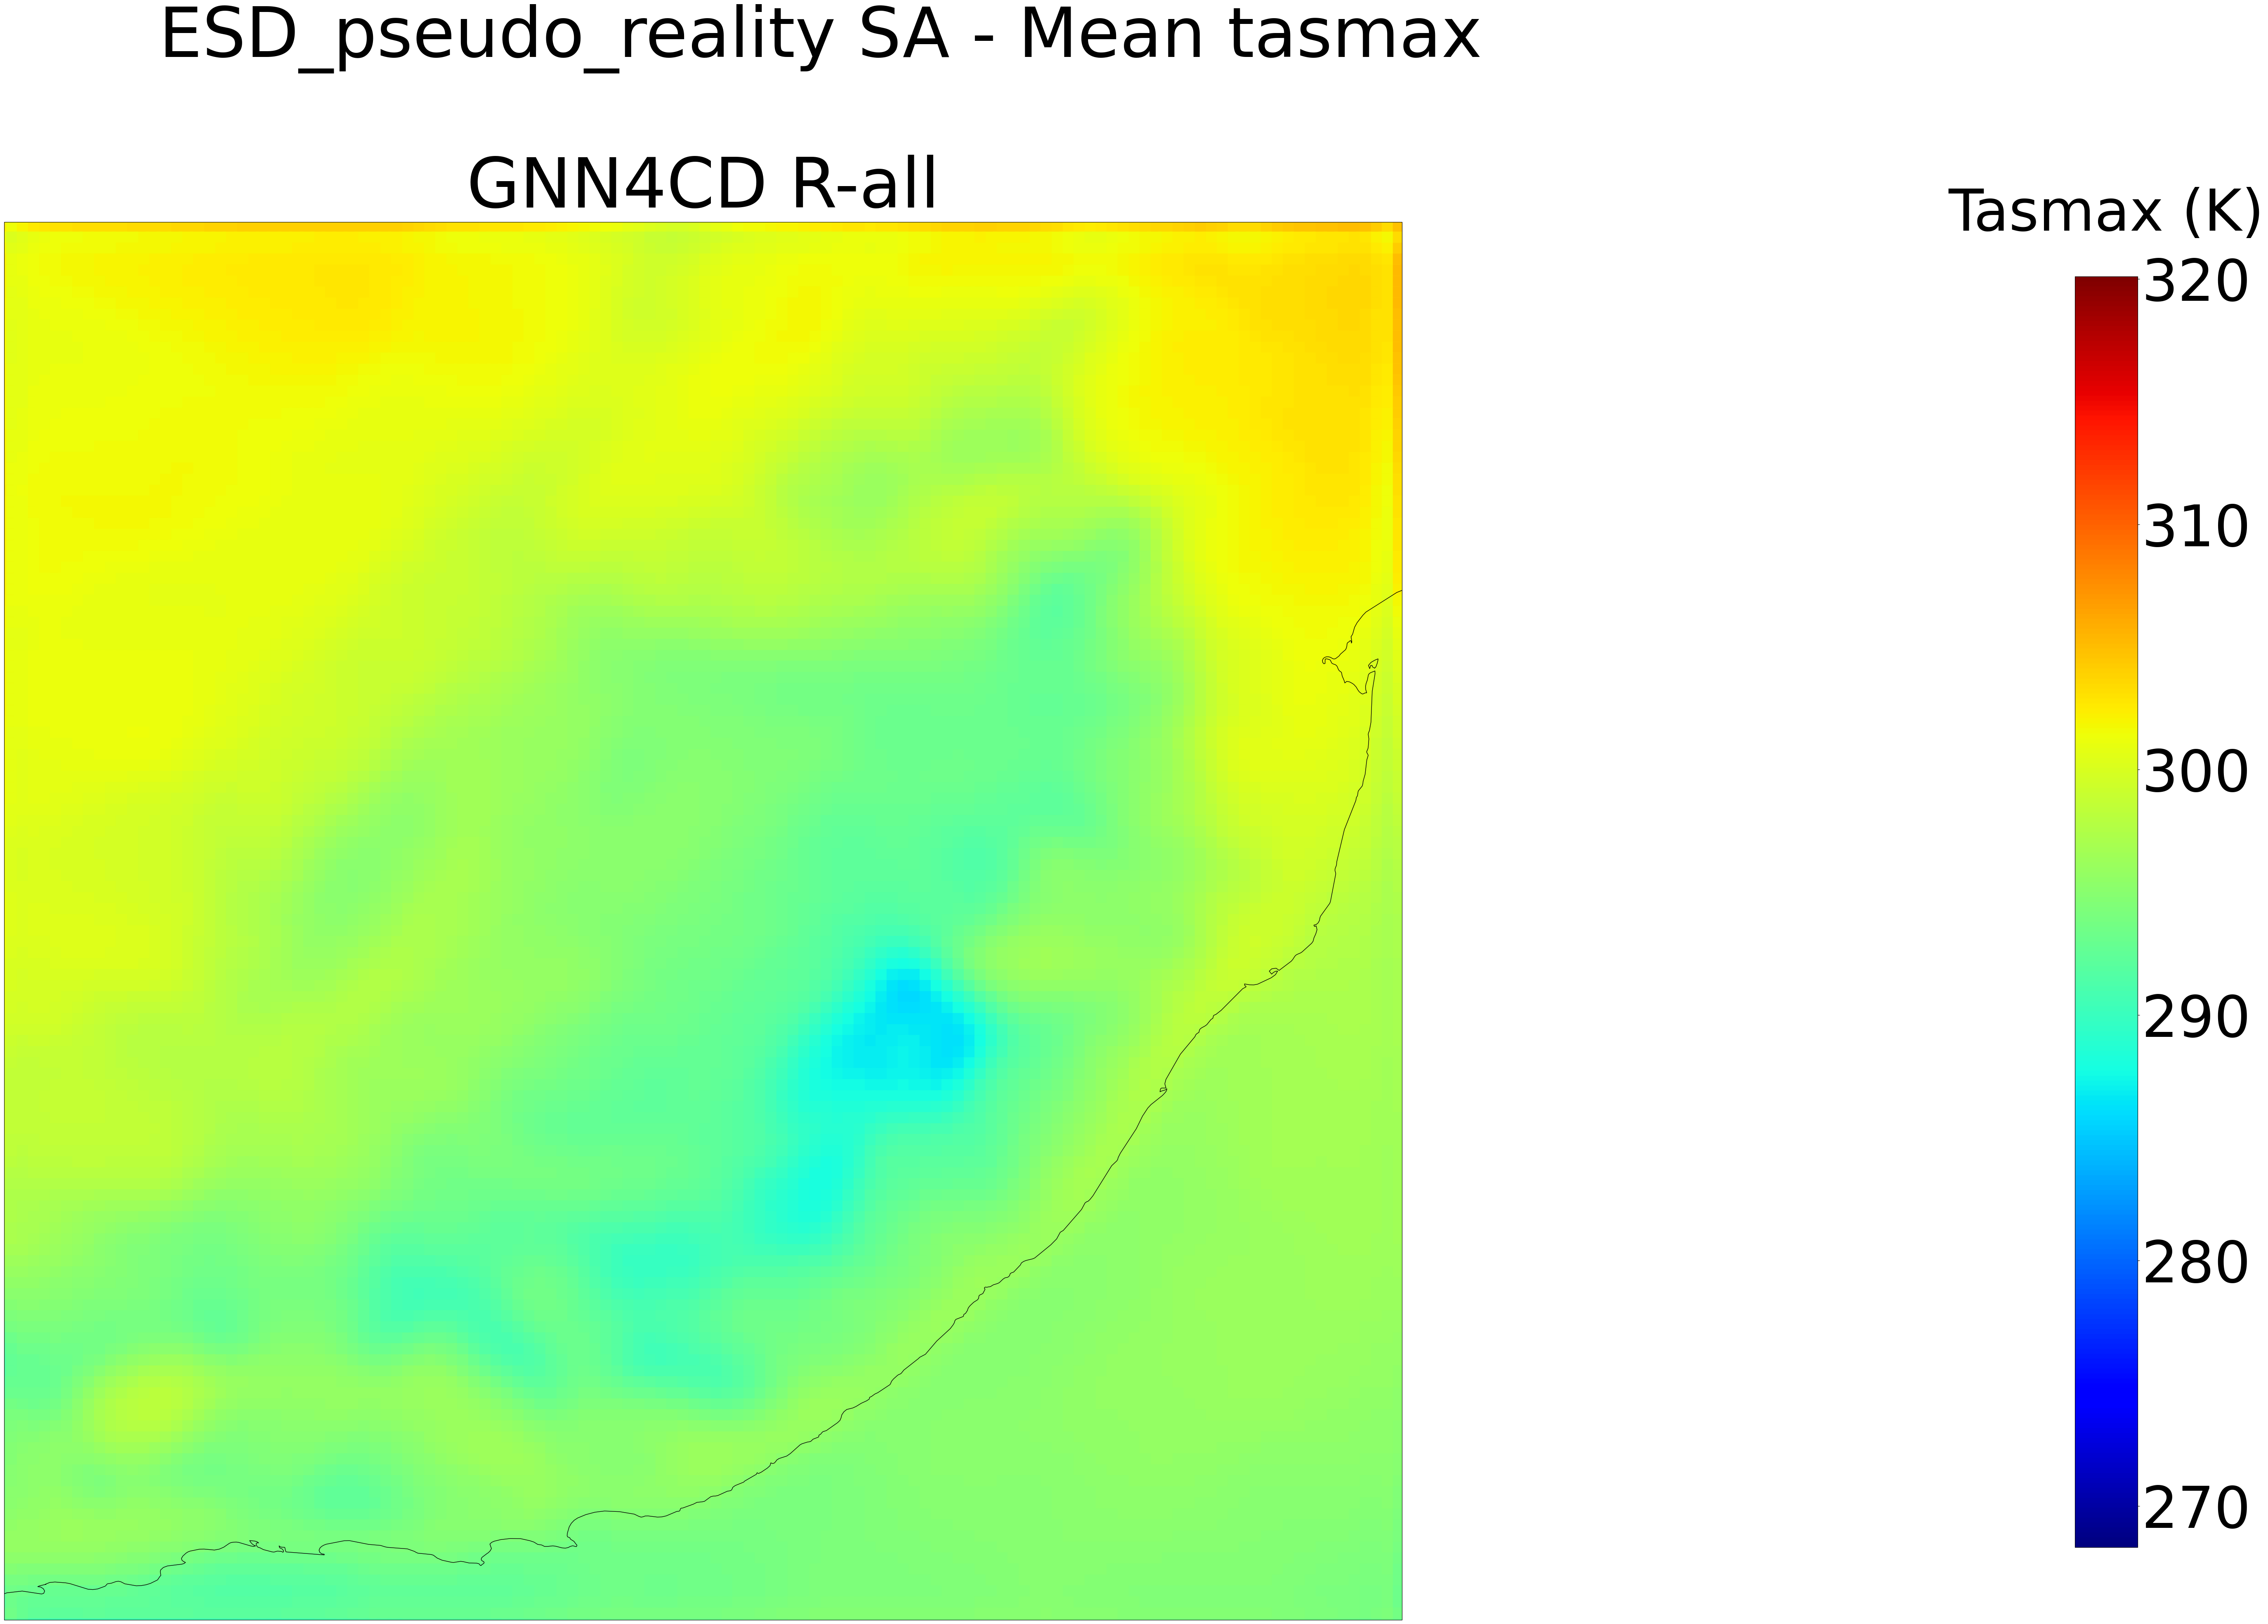

In [59]:

day_start = 1
month_start = 1
year_start = 1975
day_end = 31
month_end = 12
year_end = 1975

x_size = 38
y_size = 44
xlim = [lon_min, lon_max]
ylim = [lat_min, lat_max]
font_size = 100
font_size_title = 120
cbar_y = 0.95
cbar_title_size = 100

tasmax_min = np.nanmin(tasmax_target)
tasmax_max = np.nanmax(tasmax_target)+1.0

plot_single_map(
    lon, lat, mean_tasmax_pred,
    domain='SA',
    tasmax_min=tasmax_min,  
    tasmax_max=tasmax_max,  
    s=1000,
    title=f"{EXPERIMENT} SA - Mean tasmax",
    legend_title="Tasmax (K)",  
    save_path=plot_path,
    save_file_name=f"{DOMAIN}_domain_{EXPERIMENT}_average_tasmax_valyear.pdf",
    x_size=x_size, y_size=y_size,
    font_size_title=font_size_title,
    font_size=font_size,
    cbar_title_size=cbar_title_size,
    ylim=ylim, xlim=xlim,
    cbar_y=cbar_y,
    subtitle_x=0.55
)


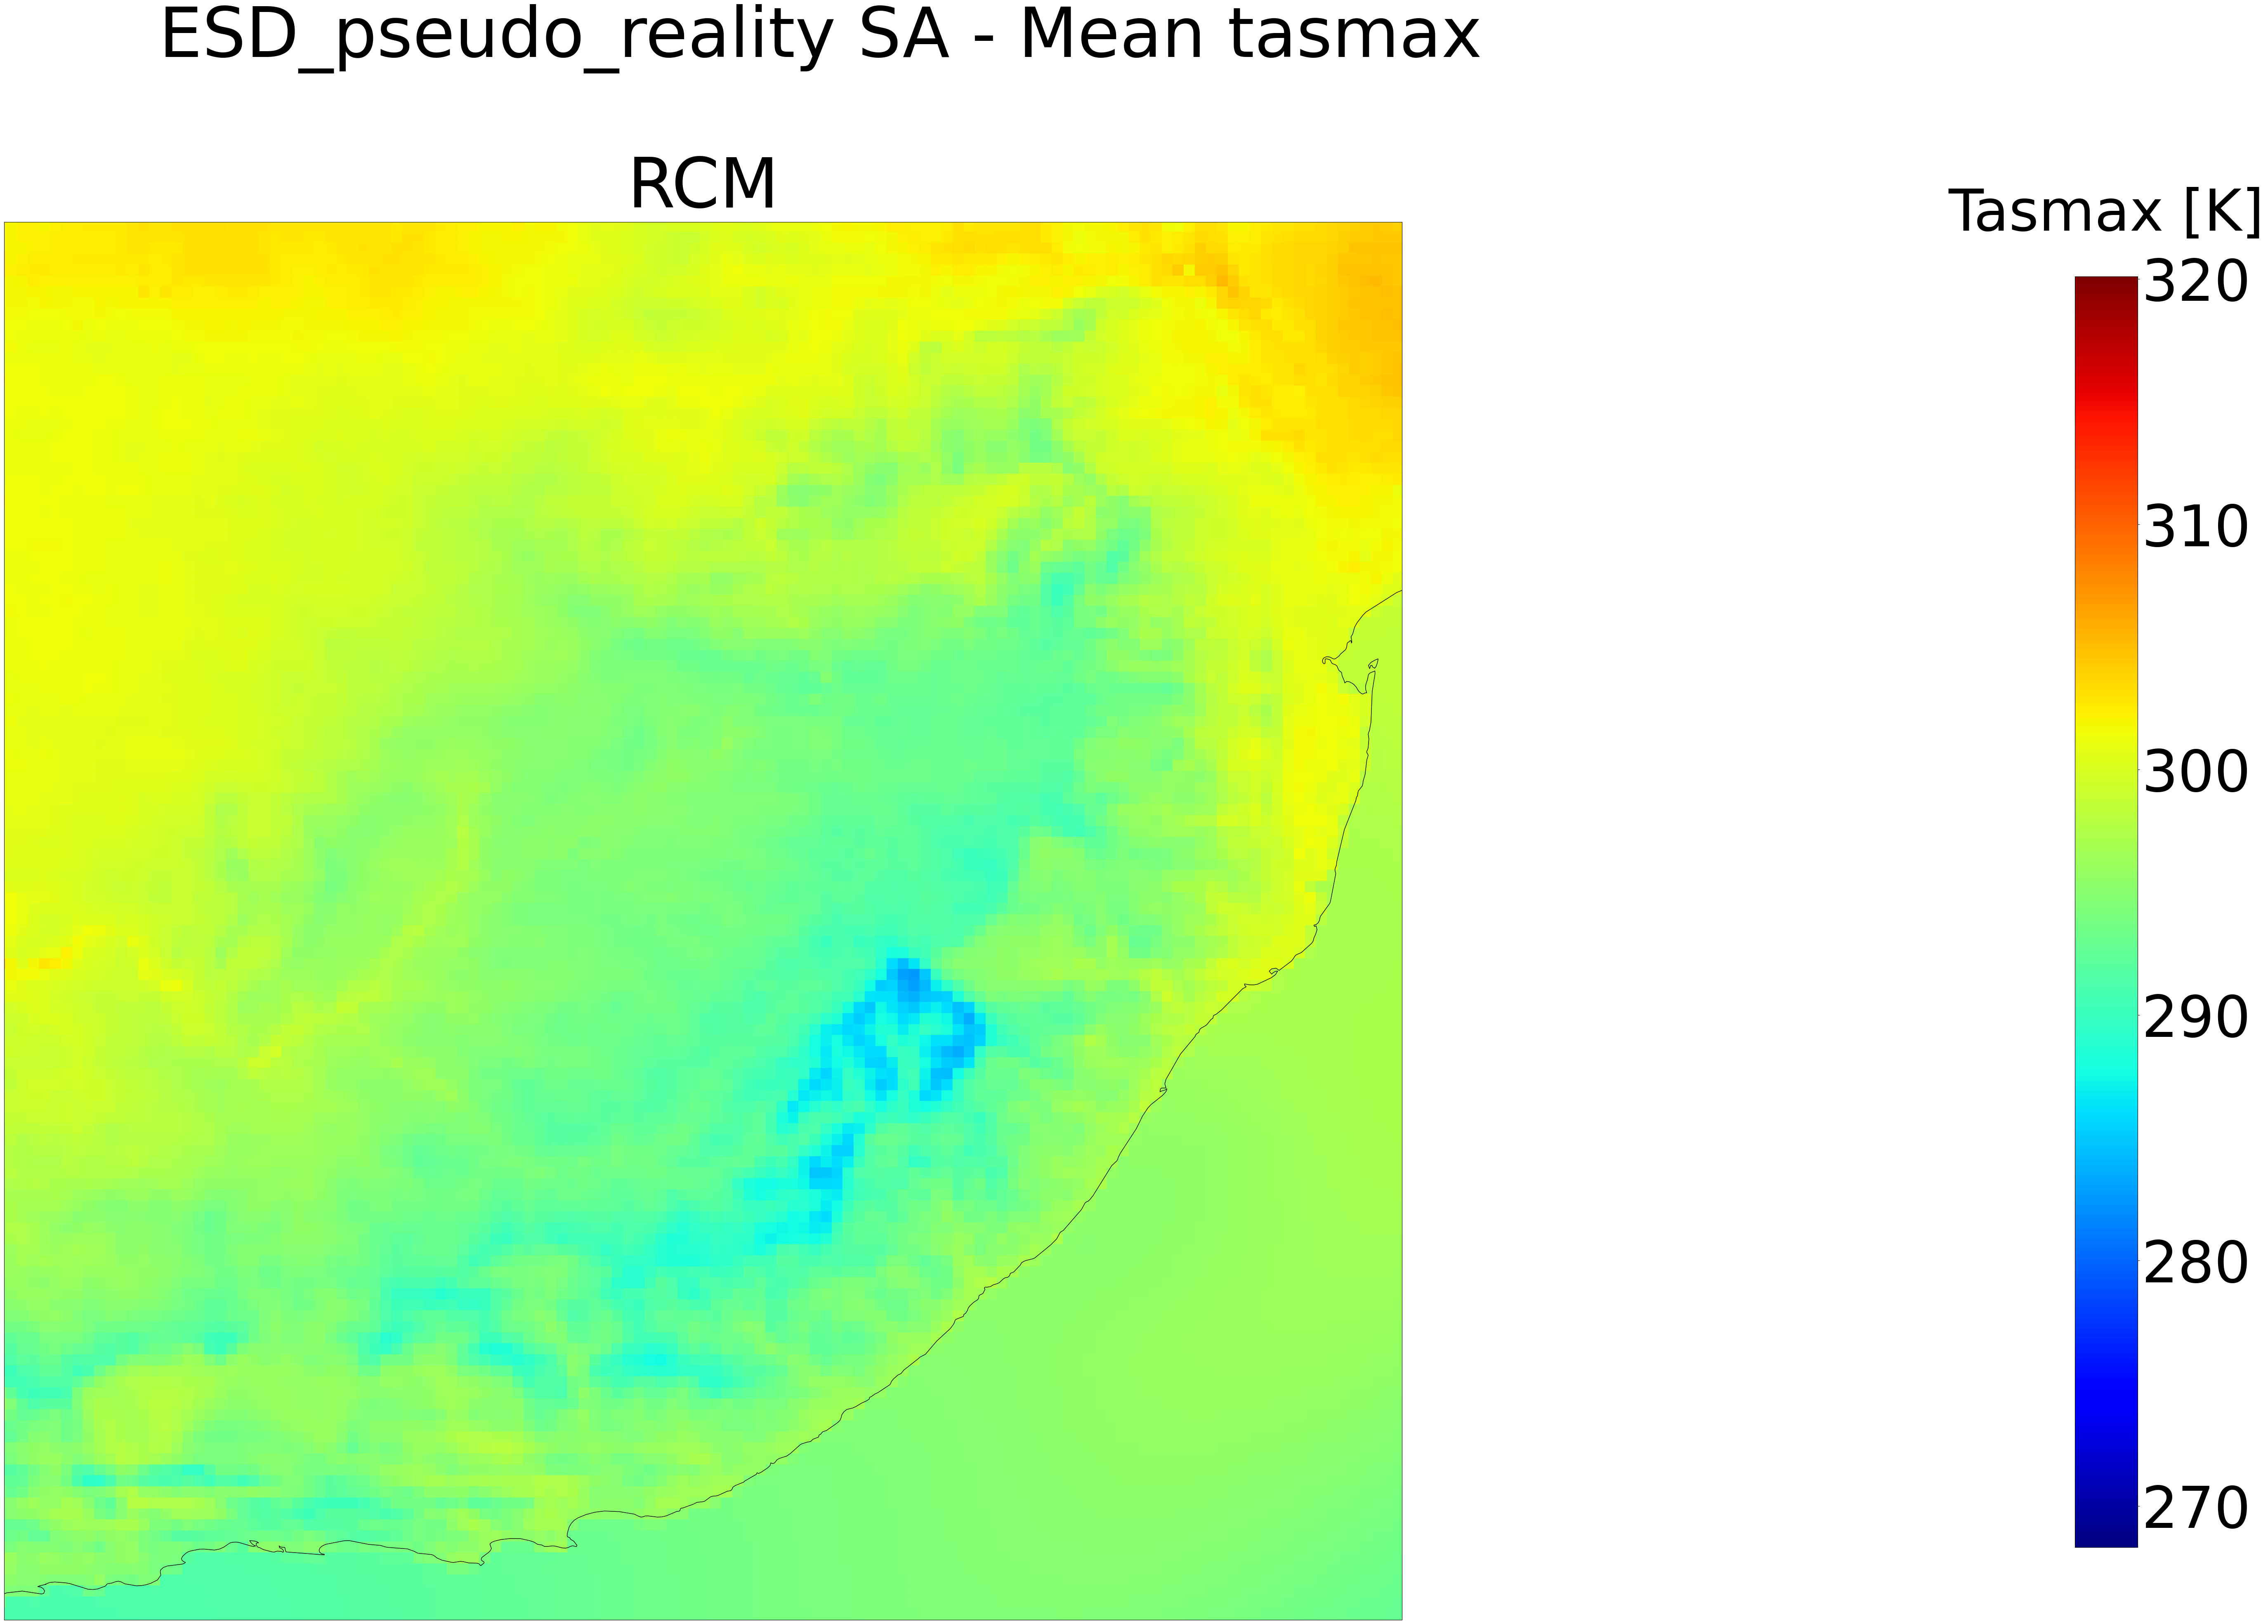

In [22]:
plot_single_map(
    lon, lat, mean_tasmax_target,
    domain='SA',
    tasmax_min=tasmax_min,  
    tasmax_max=tasmax_max,  
    s=1000,
    emulator='no',
    title=f"{EXPERIMENT} SA - Mean tasmax",
    legend_title="Tasmax [K]",  
    save_path=plot_path,
    save_file_name=f"{DOMAIN}_domain_{EXPERIMENT}_average_tasmax_target_valyear.pdf",
    x_size=x_size, y_size=y_size,
    font_size_title=font_size_title,
    font_size=font_size,
    cbar_title_size=cbar_title_size,
    ylim=ylim, xlim=xlim,
    cbar_y=cbar_y,
    subtitle_x=0.55
)

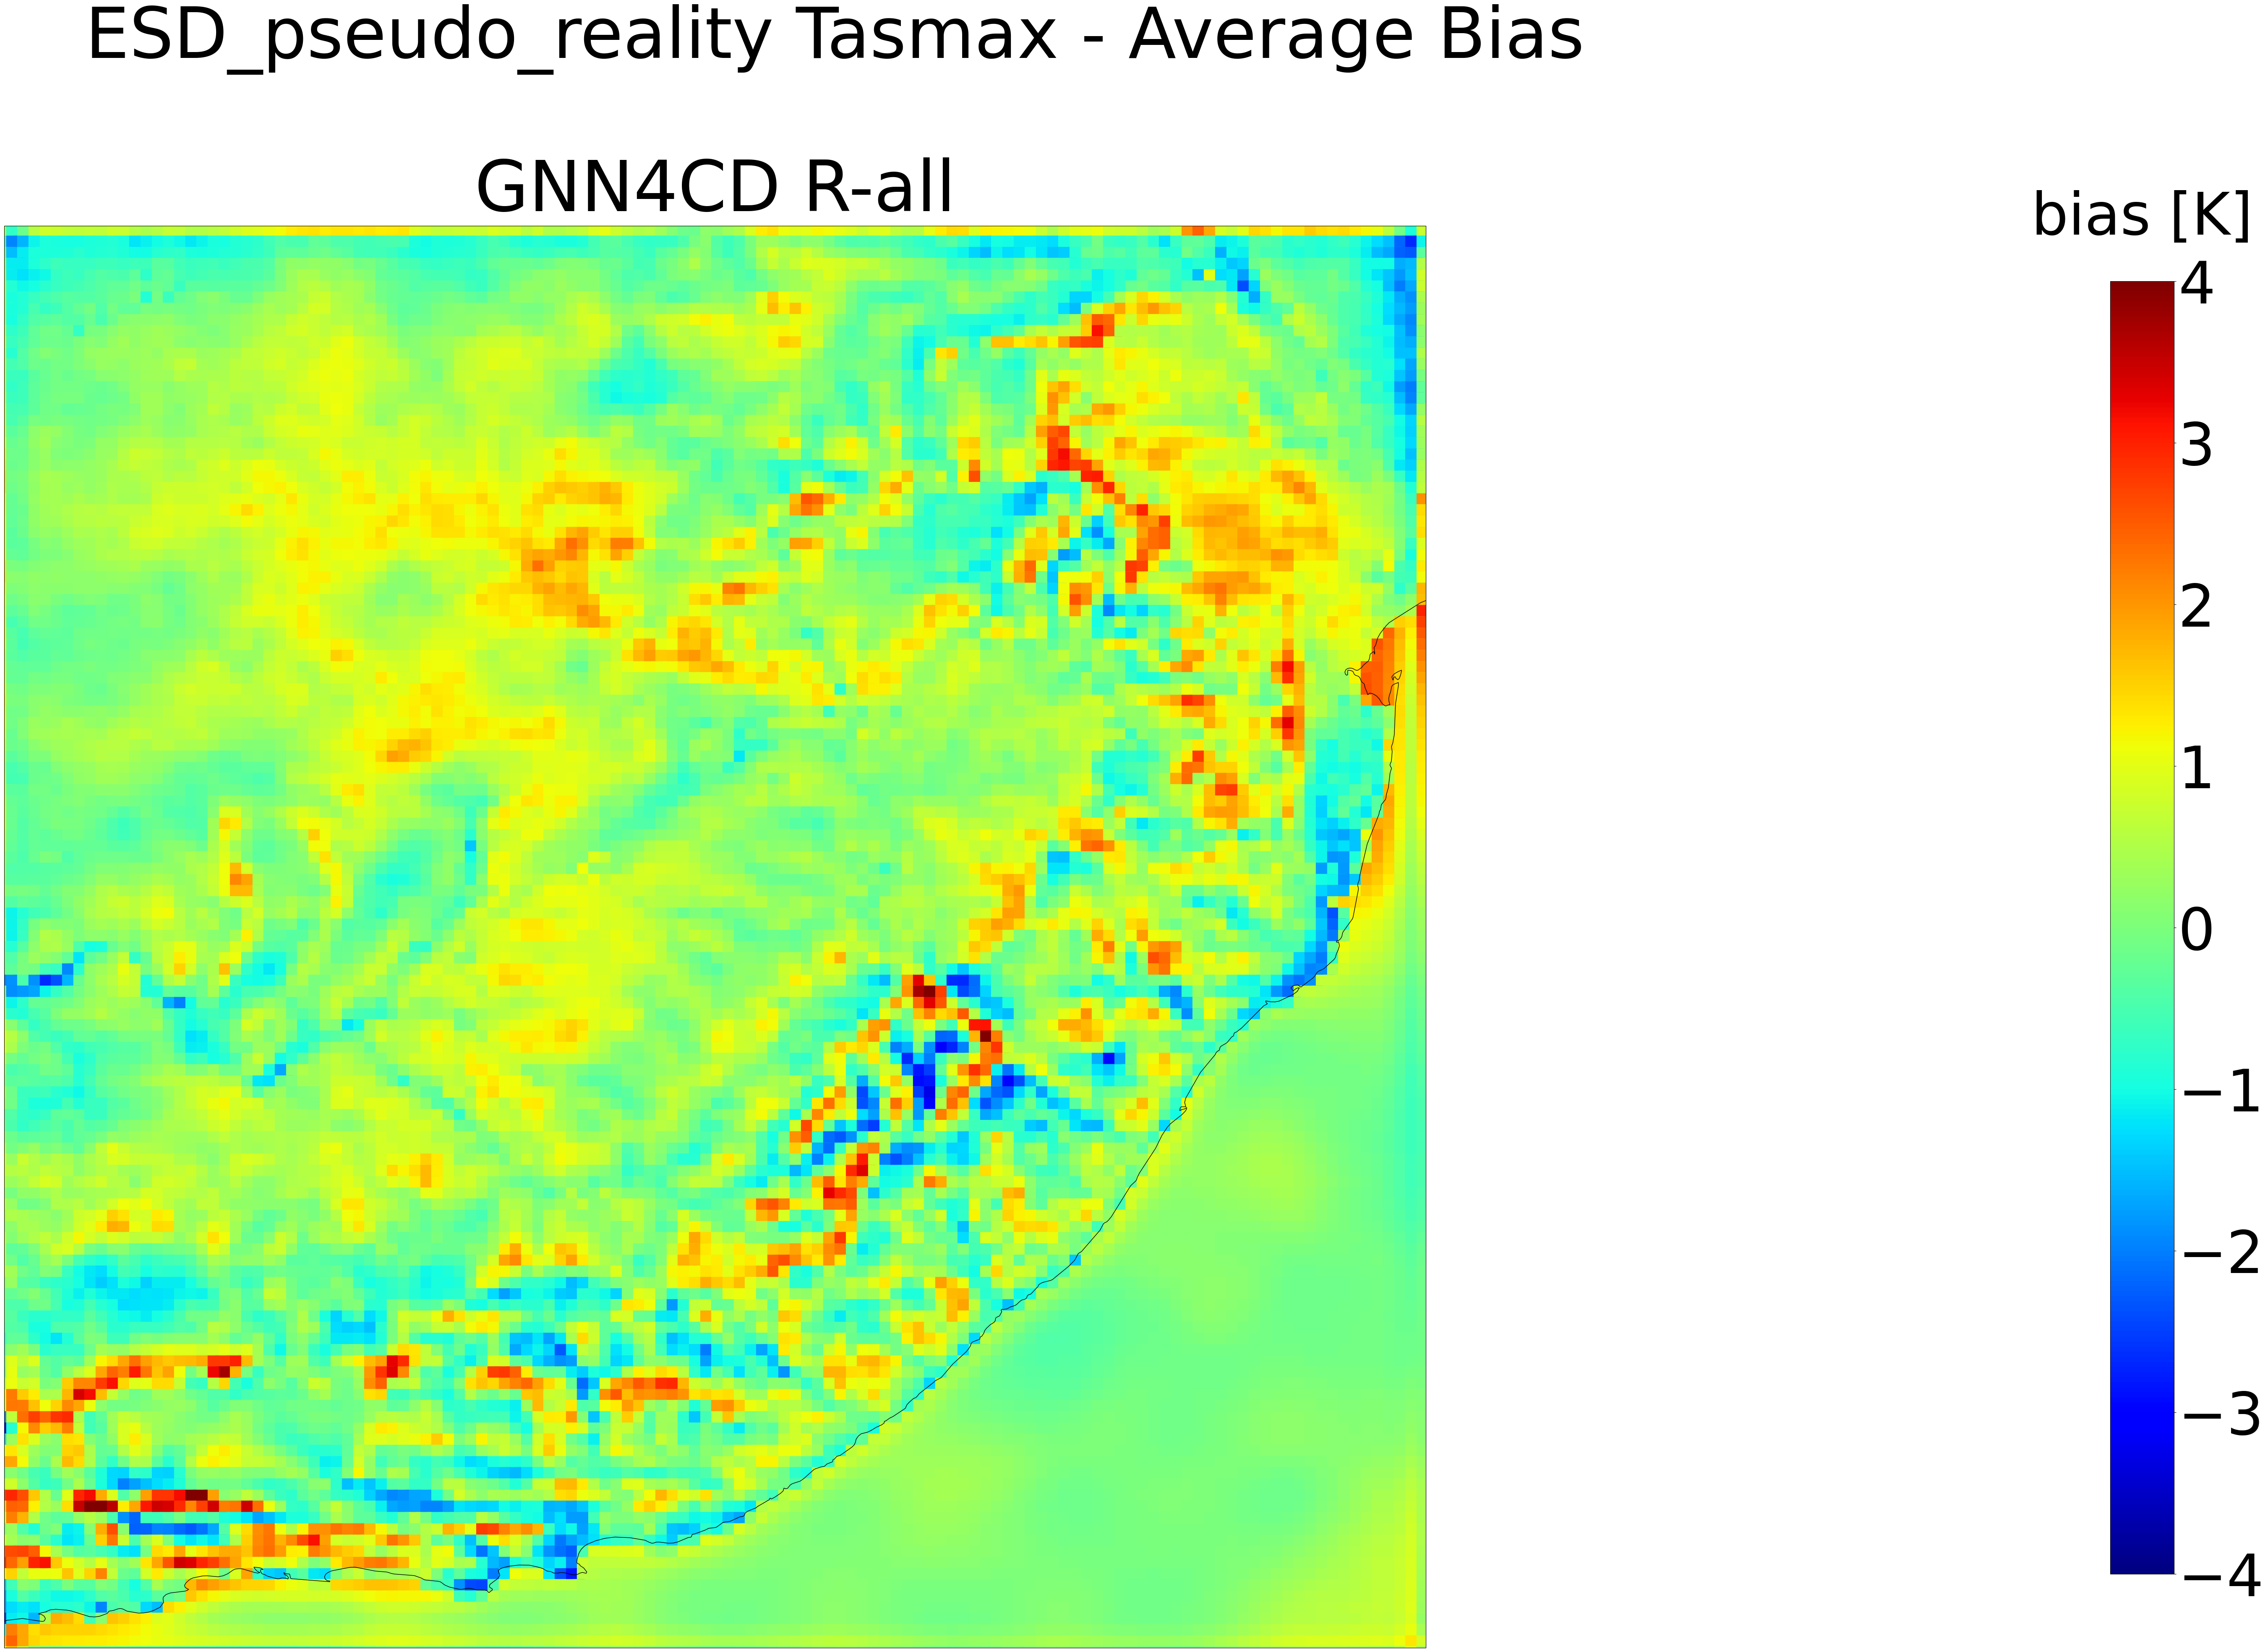

In [60]:
plot_single_map(
    lon, lat, tasmax_avg_bias,
    domain='SA',
    # tasmax_min=tasmax_avg_bias.min(),  
    # tasmax_max=tasmax_avg_bias.max(), 
    tasmax_min=-4,
    tasmax_max=4,
    s=1000,
    title=f"{EXPERIMENT} Tasmax - Average Bias",
    legend_title="bias [K]",  
    save_path=plot_path,
    save_file_name=f"{DOMAIN}_domain_{EXPERIMENT}_average_tasmax_bias_valyear.pdf",
    x_size=x_size, y_size=y_size,
    font_size_title=font_size_title,
    font_size=font_size,
    cbar_title_size=cbar_title_size,
    ylim=ylim, xlim=xlim,
    cbar_y=cbar_y,
    subtitle_x=0.55
)


In [55]:

Seasons_list = ['DJF', 'MAM', 'JJA', 'SON']
print(pr_pred_seasons[0].mean(axis=1).size)

16384


In [61]:
print(f"\n=== tasmax Statistics (K) ===")
print(f"Target - Mean: {np.nanmean(tasmax_target):.2f}, Std: {np.nanstd(tasmax_target):.2f}")
print(f"Target - Min: {np.nanmin(tasmax_target):.2f}, Max: {np.nanmax(tasmax_target):.2f}")
print(f"Prediction - Mean: {np.nanmean(tasmax_pred):.2f}, Std: {np.nanstd(tasmax_pred):.2f}")
print(f"Prediction - Min: {np.nanmin(tasmax_pred):.2f}, Max: {np.nanmax(tasmax_pred):.2f}")
print(f"Bias - Mean: {np.nanmean(tasmax_pred - tasmax_target):.2f}")
print(f"RMSE: {np.sqrt(np.nanmean((tasmax_pred - tasmax_target)**2)):.2f}")


=== tasmax Statistics (K) ===
Target - Mean: 296.50, Std: 6.84
Target - Min: 268.32, Max: 319.09
Prediction - Mean: 296.79, Std: 6.78
Prediction - Min: 271.29, Max: 320.39
Bias - Mean: 0.28
RMSE: 1.77



Plotting average target maps...


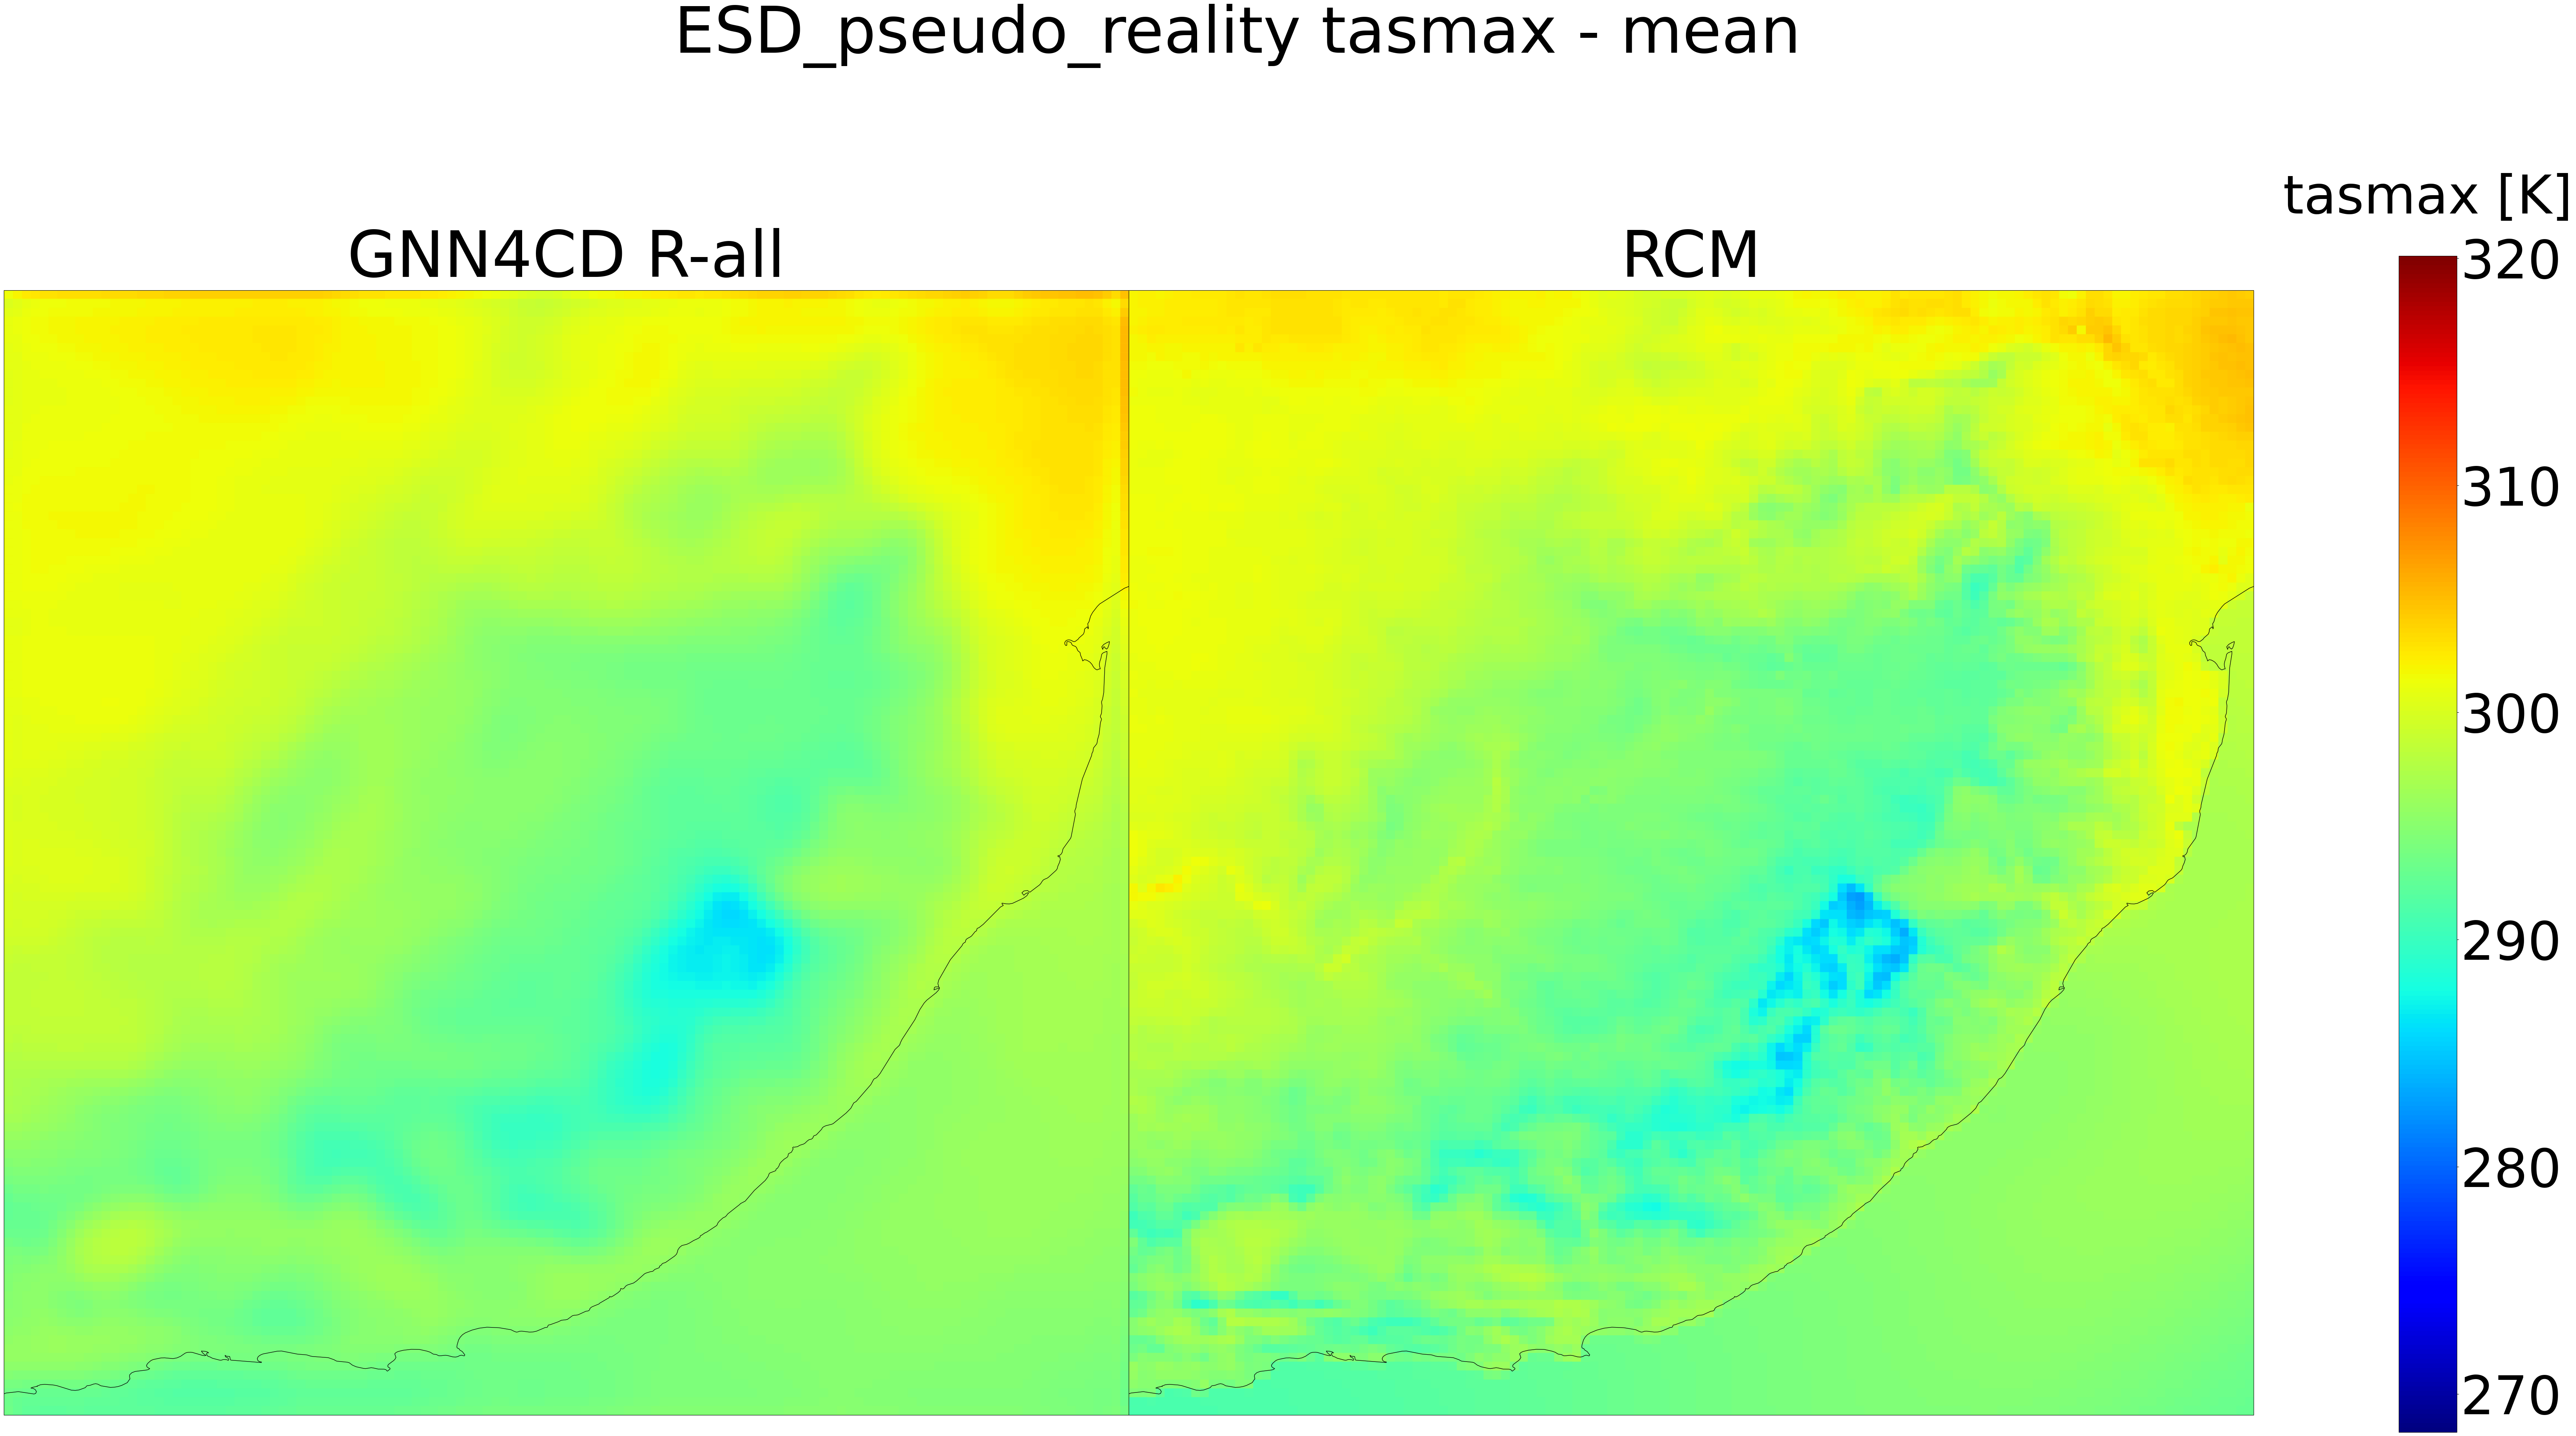

In [62]:
print("\nPlotting average target maps...")
plot_maps_new(
    lon, lat, tasmax_pred, tasmax_target,
    domain='SA',
    pr_min=tasmax_min,  
    aggr=np.nanmean,  
    pr_max=tasmax_max,  
    s=1000,
    title=f"{EXPERIMENT} tasmax - mean",
    legend_title="tasmax [K]",  
    save_path=plot_path,
    save_file_name=f"{DOMAIN}_domain_{EXPERIMENT}_comparison_average_tasmax_valyear.pdf",
    x_size=x_size, y_size=y_size,
    font_size_title=font_size_title,
    font_size=font_size,
    cbar_title_size=cbar_title_size,
    ylim=ylim, xlim=xlim,
    cbar_y=cbar_y,
    subtitle_x=0.55
)


def q95(x, **kwargs):
    return np.quantile(x, 0.95, **kwargs)

def q99(x, **kwargs):
    return np.quantile(x, 0.99, **kwargs)


Plotting maximum temperature maps...


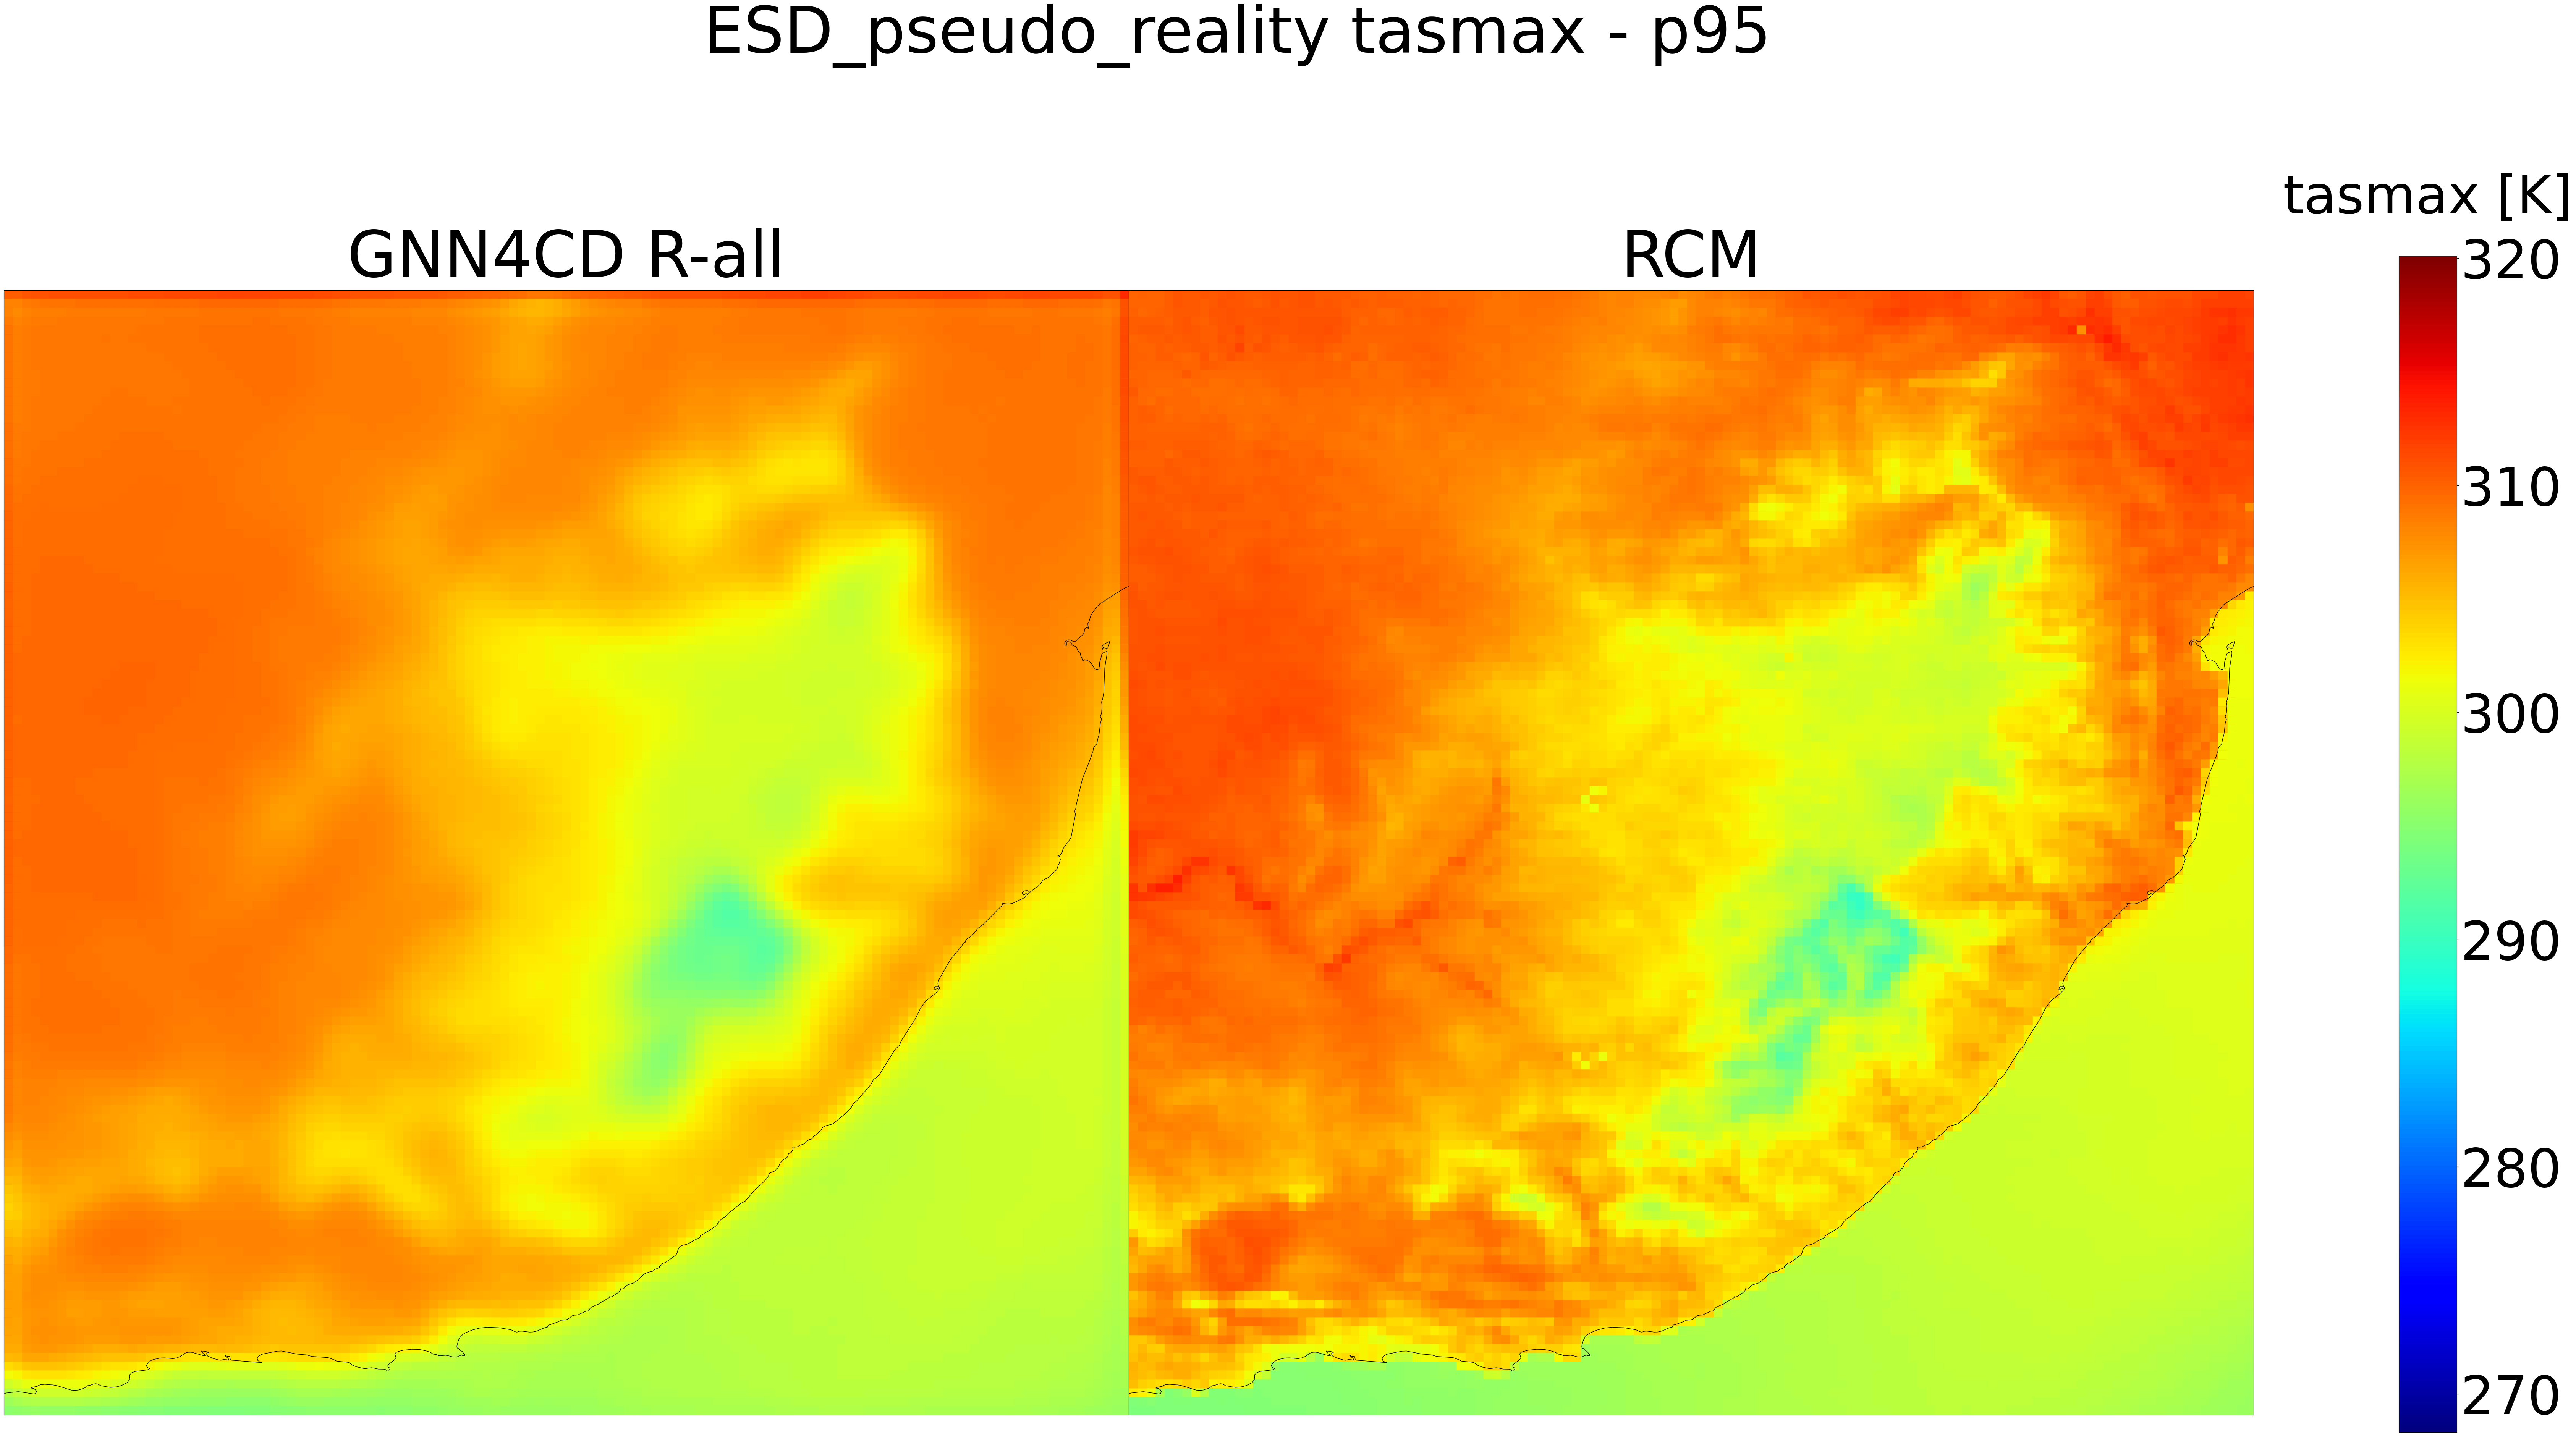

In [63]:

print("\nPlotting maximum temperature maps...")
plot_maps_new(
    lon, lat, tasmax_pred, tasmax_target,
    domain='SA',
    pr_min=tasmax_min,
    aggr=q95,  
    pr_max=tasmax_max,
    s=1000,
    title=f"{EXPERIMENT} tasmax - p95",
    legend_title="tasmax [K]",
    save_path=plot_path,
    save_file_name=f"{DOMAIN}_domain_{EXPERIMENT}_comparison_tasmax95_valyear.pdf",
    x_size=x_size, y_size=y_size,
    font_size_title=font_size_title,
    font_size=font_size,
    cbar_title_size=cbar_title_size,
    ylim=ylim, xlim=xlim,
    cbar_y=cbar_y,
    subtitle_x=0.55
)



Plotting maximum temperature maps...


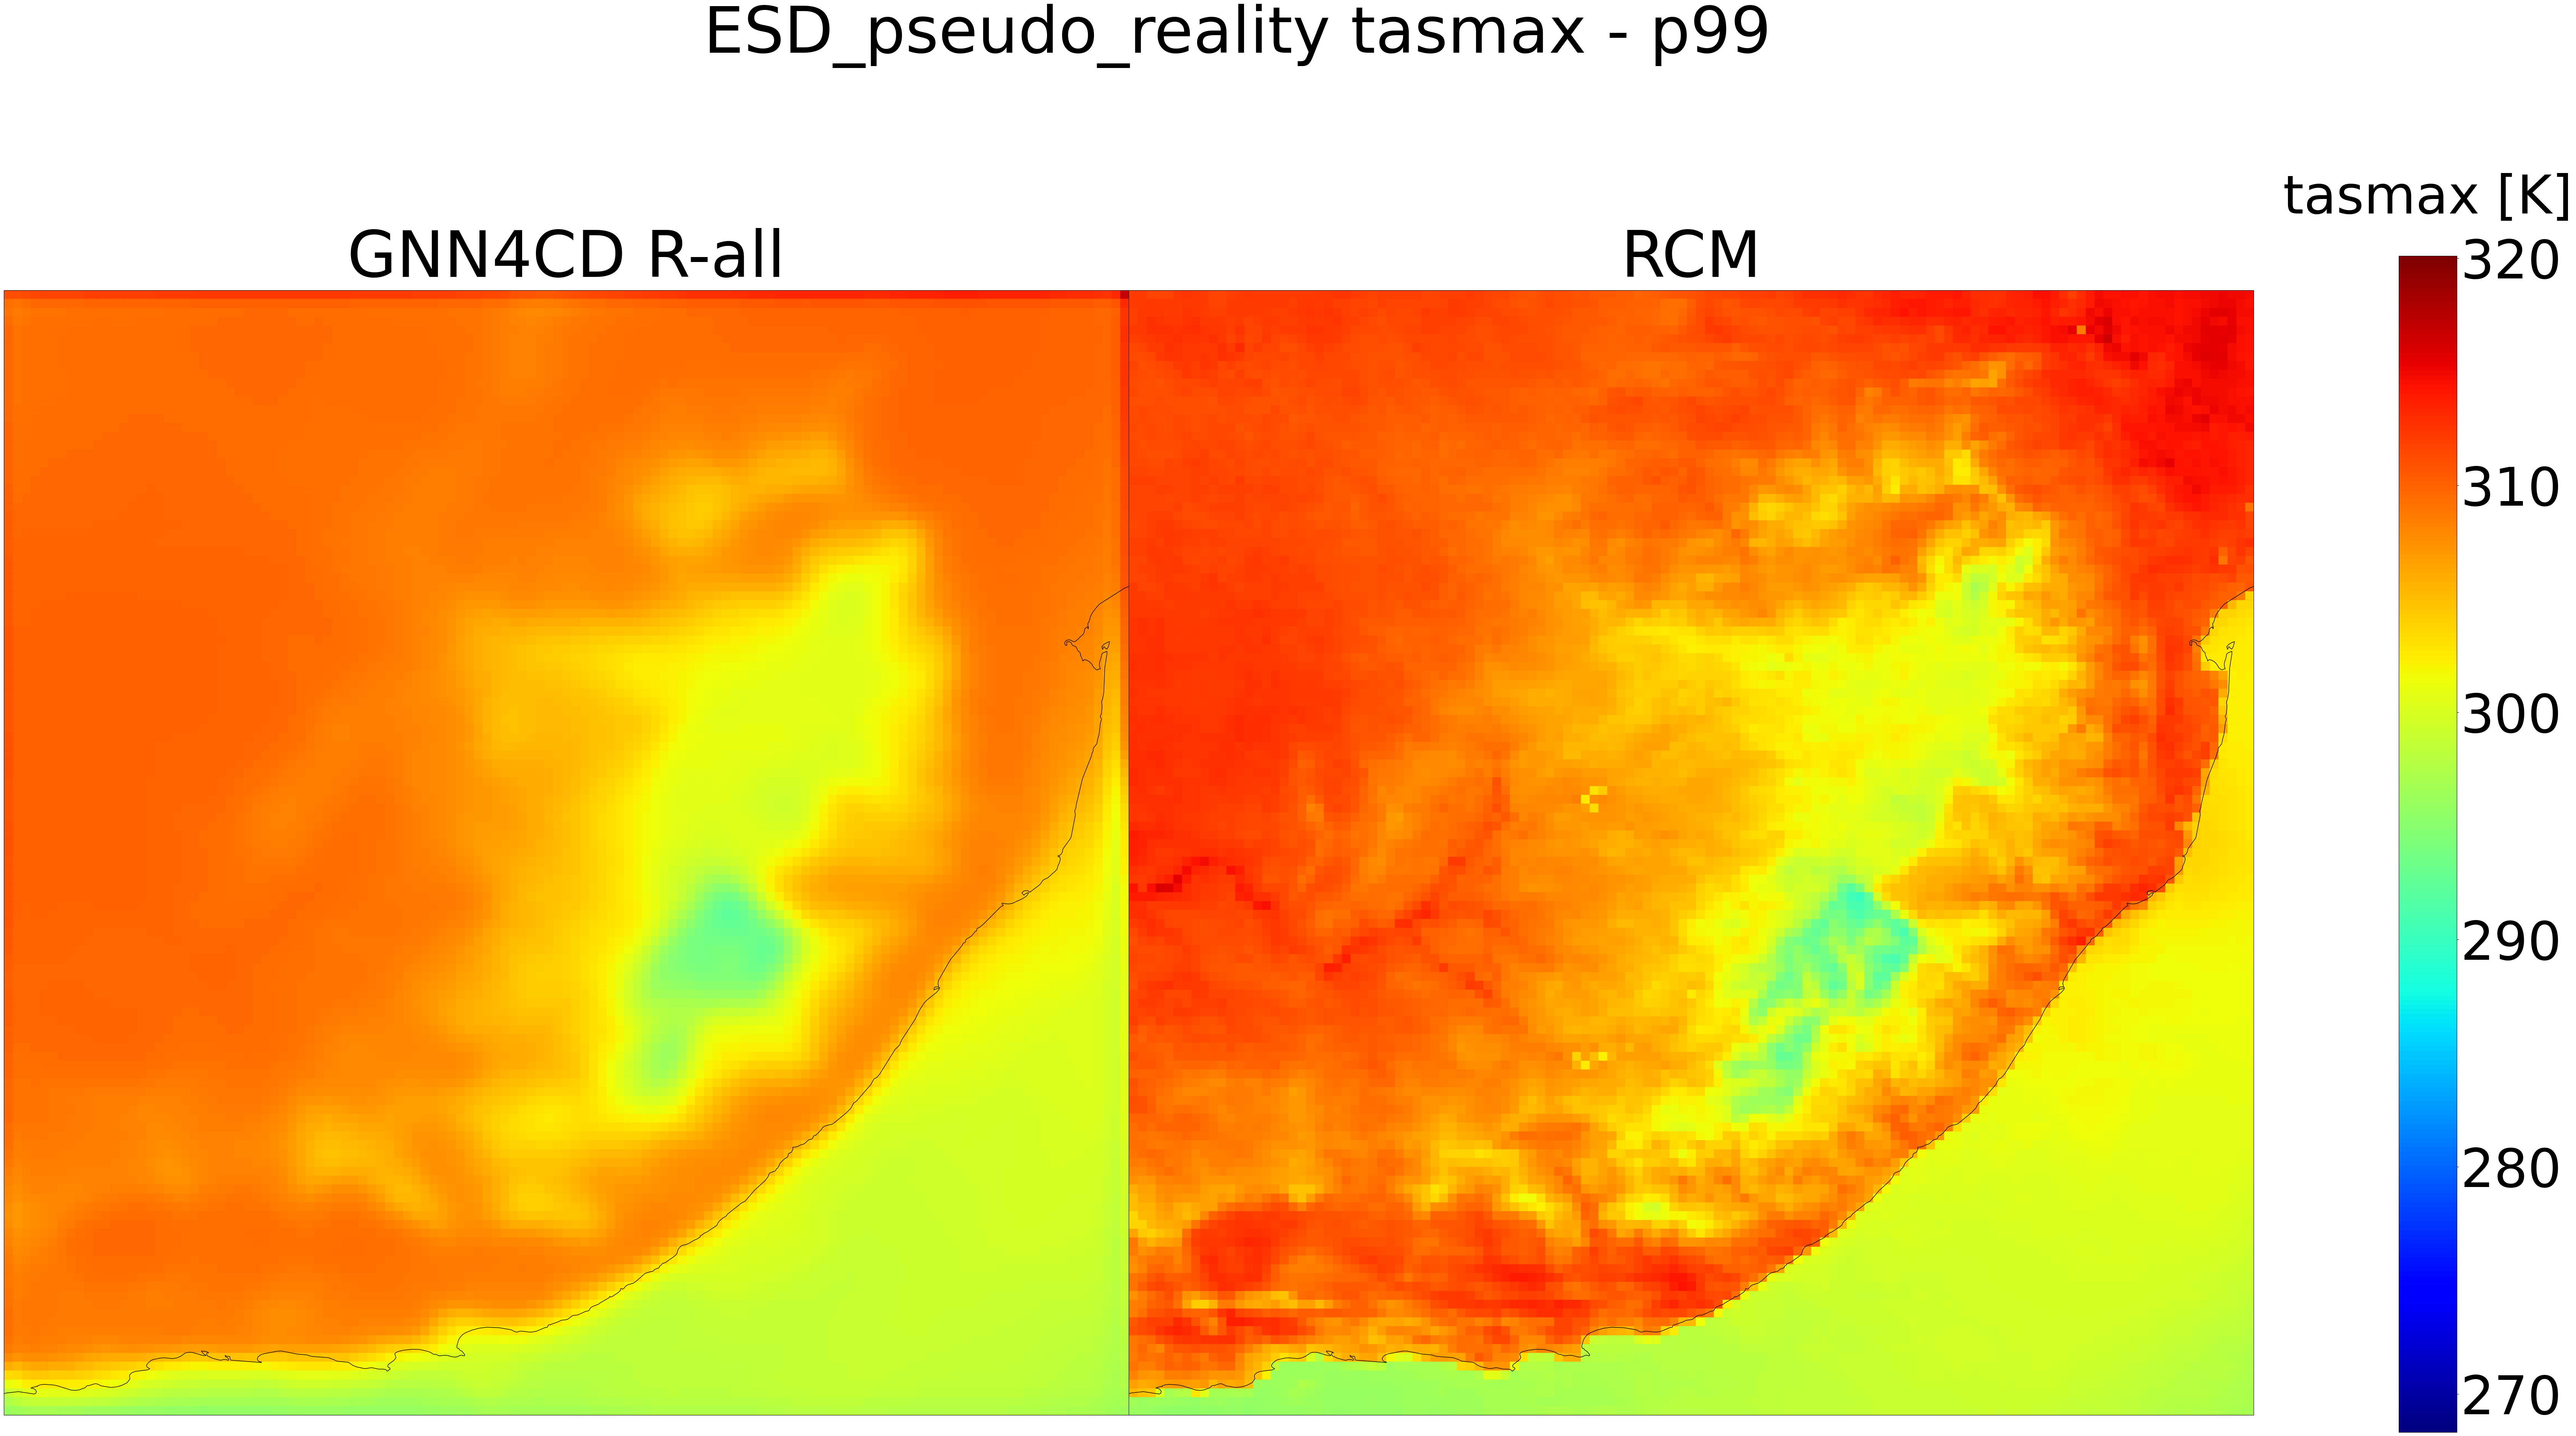

In [64]:
print("\nPlotting maximum temperature maps...")
plot_maps_new(
    lon, lat, tasmax_pred, tasmax_target,
    domain='SA',
    pr_min=tasmax_min,
    aggr=q99,  
    pr_max=tasmax_max,
    s=1000,
    title=f"{EXPERIMENT} tasmax - p99",
    legend_title="tasmax [K]",
    save_path=plot_path,
    save_file_name=f"{DOMAIN}_domain_{EXPERIMENT}_comparison_tasmax99_valyear.pdf",
    x_size=x_size, y_size=y_size,
    font_size_title=font_size_title,
    font_size=font_size,
    cbar_title_size=cbar_title_size,
    ylim=ylim, xlim=xlim,
    cbar_y=cbar_y,
    subtitle_x=0.55
)

In [34]:
def plot_seasonal_maps(pos, tasmax, tasmax_min, tasmax_max, title="", cmap='jet', cmap_type=None, unit="[K]", norm=None, s=10, domain="NZ", legend_title='tasmax'):
    plt.rcParams.update({'font.size': 70})
    if domain == 'NZ':
        central_longitude=180.0
    else:
        central_longitude=0.0
    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(100,24), subplot_kw={"projection": proj})

    # Define cmaps
    if cmap_type is None:
        tasmax_min = tasmax_min if tasmax_min is not None else np.nanmin(np.nanmin(tasmax_pred), np.nanmin(tasmax))
        tasmax_max = tasmax_max if tasmax_max is not None else np.nanmax(np.nanmax(tasmax_pred), np.nanmax(tasmax))
        
    if cmap_type == "custom_blue_discrete_avg":
        c_list = ["#F8FBFE",
                  "#E1EBF6",
                  "#CADBED",
                  "#A7C9DE",
                  "#7AADD2",
                  "#5691C1",
                  "#3771B0",
                  "#205297",
                  "#123167"]

        cmap = matplotlib.colors.ListedColormap(c_list, name='cmap_blue', N=len(c_list)) # N=cmap.shape[0])
        # Bounds may be unevenly spaced:
        bounds = np.array([0.0, 0.1, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 20.0, 30.0])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=len(c_list))
    elif cmap_type == "custom_jet_discrete_avg":
        bounds = np.array([0.0, 0.1, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 7.5, 10.0, 12.5, 15.0])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
    elif cmap_type == "custom_jet_discrete_avg2":
        bounds = np.array([260, 265, 270, 275, 280, 285, 290, 295, 300,305,310,315,320])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
    elif cmap_type == "custom_jet_discrete_avg_limits":
        bounds = bounds
        # bounds = np.linspace(pr_min, pr_max, num)
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)
    elif cmap_type == "custom_bwr_discrete_avg":
        bounds = np.array([-100,-50,-25,-10,-5,5,10,50,100,150])
        norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)

    ax_list = [ax[0], ax[1], ax[2], ax[3]]
    text_list = ['DJF', 'MAM', 'JJA', 'SON']

    lon = pos[:,0]
    lat = pos[:,1]

    for season in range(4):
        axi = ax_list[season]
        v = tasmax[season]
        v_mean=v.mean(axis=1)
        if cmap_type is None:
            im = axi.scatter(lon,lat,c=v_mean, marker="s", s=s, vmin=tasmax_min, vmax=tasmax_max, cmap=cmap)
        else:
            im = axi.scatter(lon,lat,c=v_mean, marker="s", s=s, norm=norm, cmap=cmap) #
        axi.coastlines(resolution='10m')
        axi.add_feature(cfeature.LAKES.with_scale("10m"))
        axi.set_xlim([lon.min()-0.25,lon.max()+0.25])
        axi.set_ylim([lat.min()-0.25,lat.max()+0.25])

        # axi.text(0.95, 0.9, text_list[s], transform=axi.transAxes,  horizontalalignment='right',fontsize=70, family='sans-serif')
        axi.set_title(text_list[season])


        if season>0:
            # axi.yaxis.set_major_locator(ticker.NullLocator())
            axi.yaxis.set_major_formatter(NullFormatter())
            for tick in axi.yaxis.get_major_ticks():
                tick.tick1line.set_visible(False)
                tick.tick2line.set_visible(False)
                tick.label1.set_visible(False)
                tick.label2.set_visible(False)

    plt.subplots_adjust(wspace=0, hspace=0)

    cbar_pad=0
    cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, aspect=25, pad=cbar_pad)
    cbar.ax.set_title(legend_title, rotation=0, fontsize=70, pad=80)

    _ = fig.suptitle(title, fontsize=70, x=0.45, y=1.015)
    #plt.savefig(f'results/cumulativeTmax_1975_seasons_predictions.png', dpi=800, bbox_inches='tight', pad_inches=0.0)


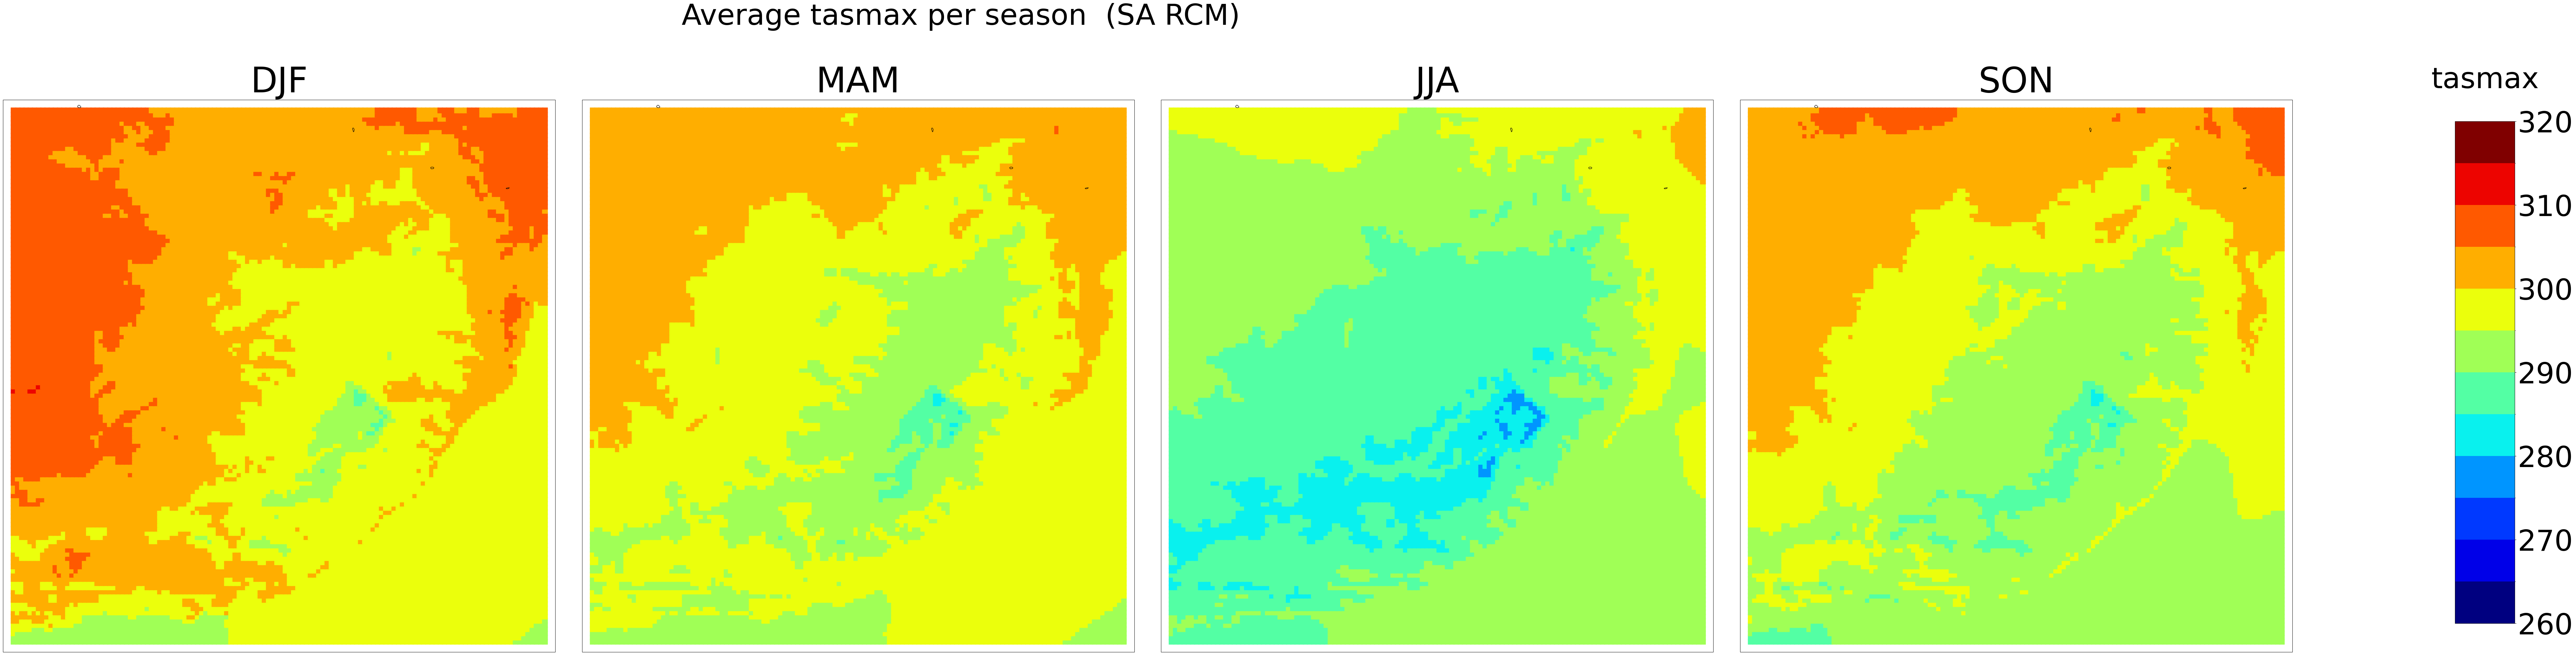

In [35]:
plot_seasonal_maps(pos, tasmax_target_seasons, tasmax_min=tasmax_min, tasmax_max=tasmax_max, title='Average tasmax per season  (SA RCM)', cmap_type='custom_jet_discrete_avg2', unit="[K]", s=150)

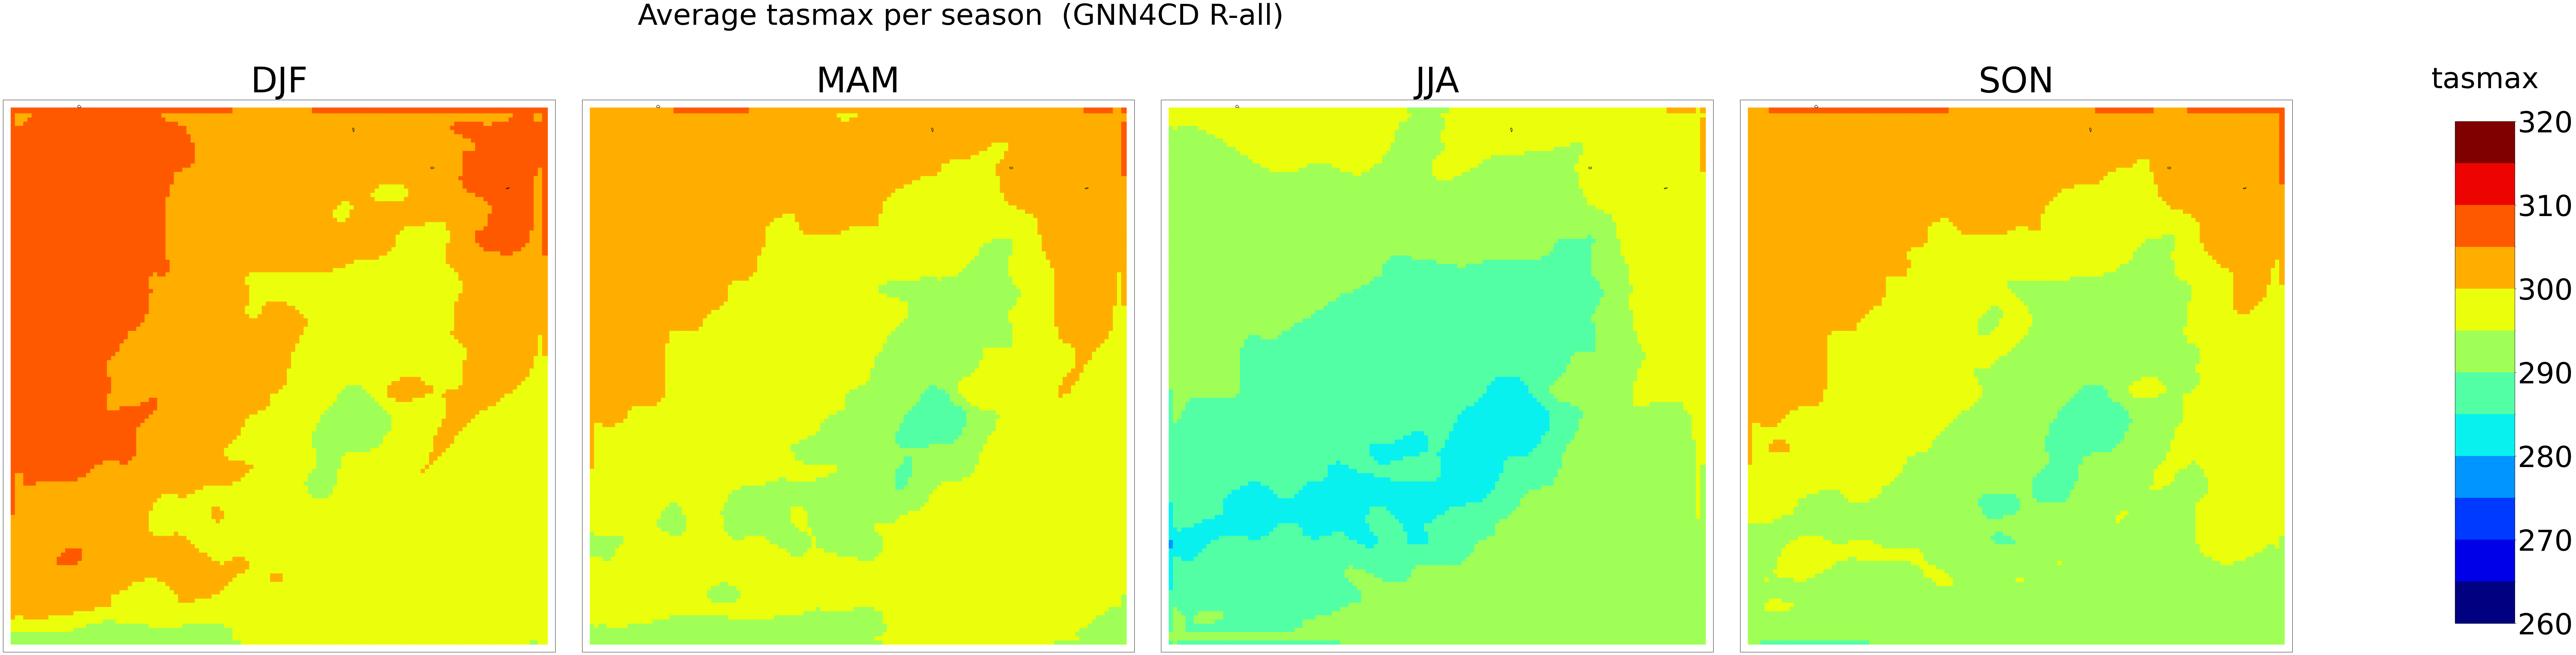

In [65]:
plot_seasonal_maps(pos, tasmax_pred_seasons, tasmax_min=tasmax_min, tasmax_max=tasmax_max, title='Average tasmax per season  (GNN4CD R-all)', cmap_type='custom_jet_discrete_avg2', unit="[K]", s=150)

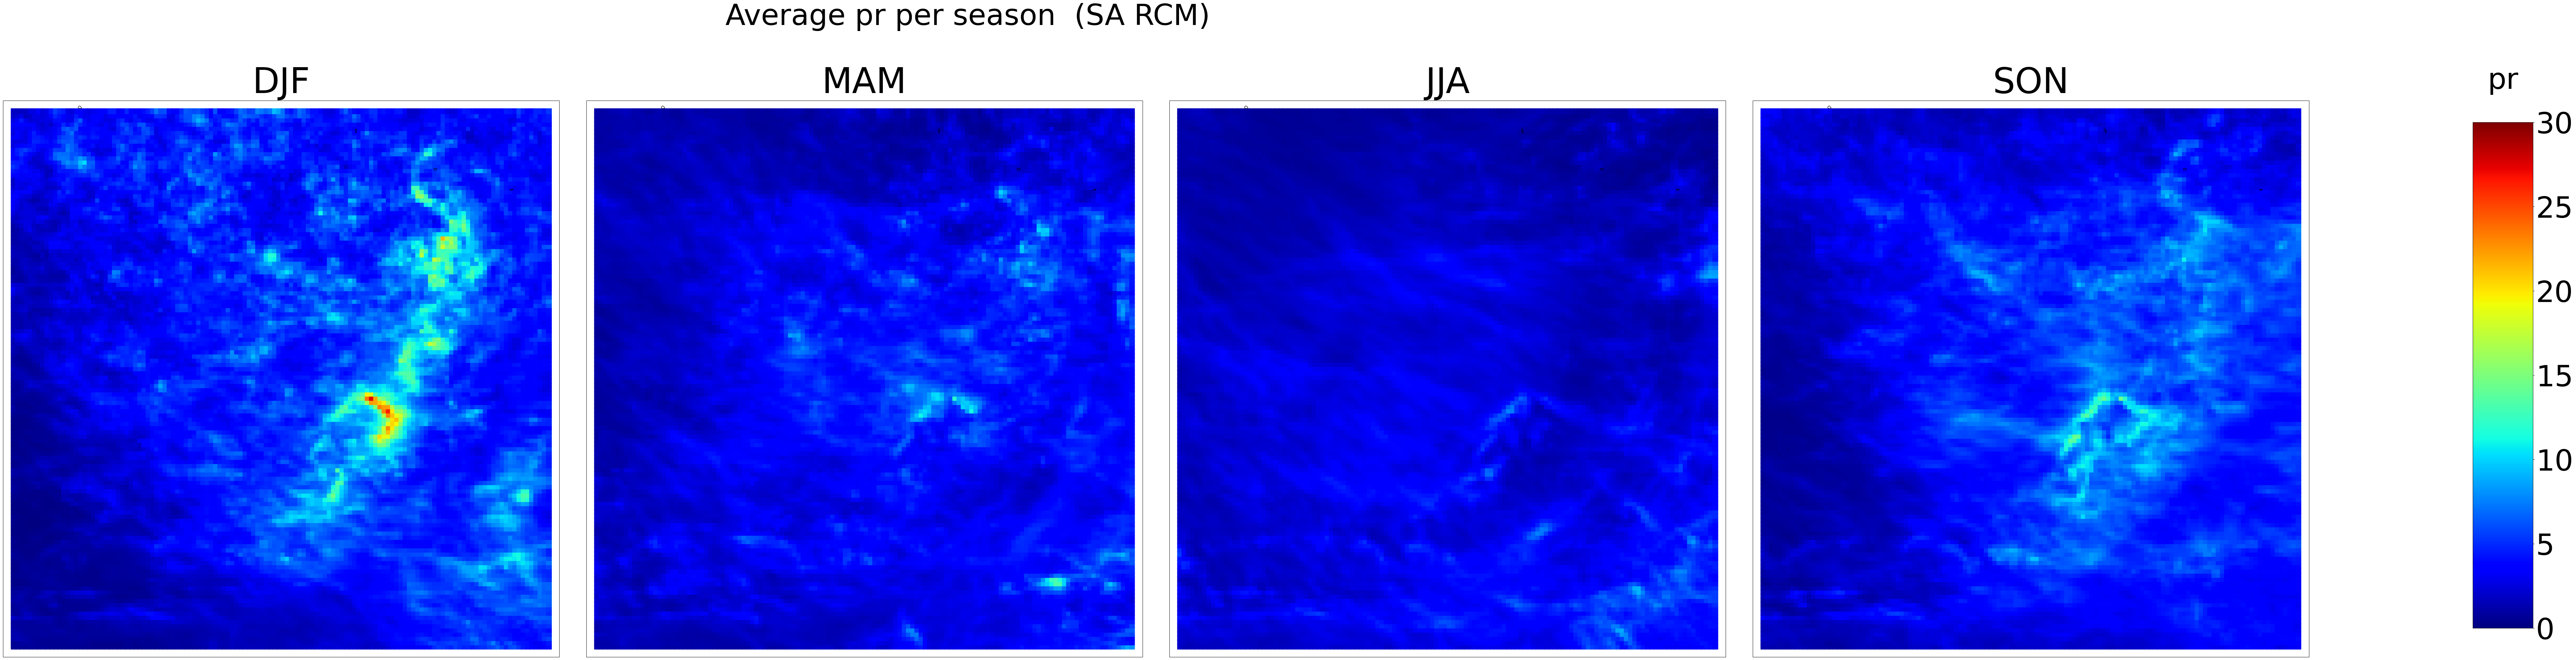

In [93]:
plot_seasonal_maps(pos, pr_target_seasons, pr_min=pr_min, pr_max=30, title='Average pr per season  (SA RCM)', cmap='jet', unit="[mm/day]", s=150)


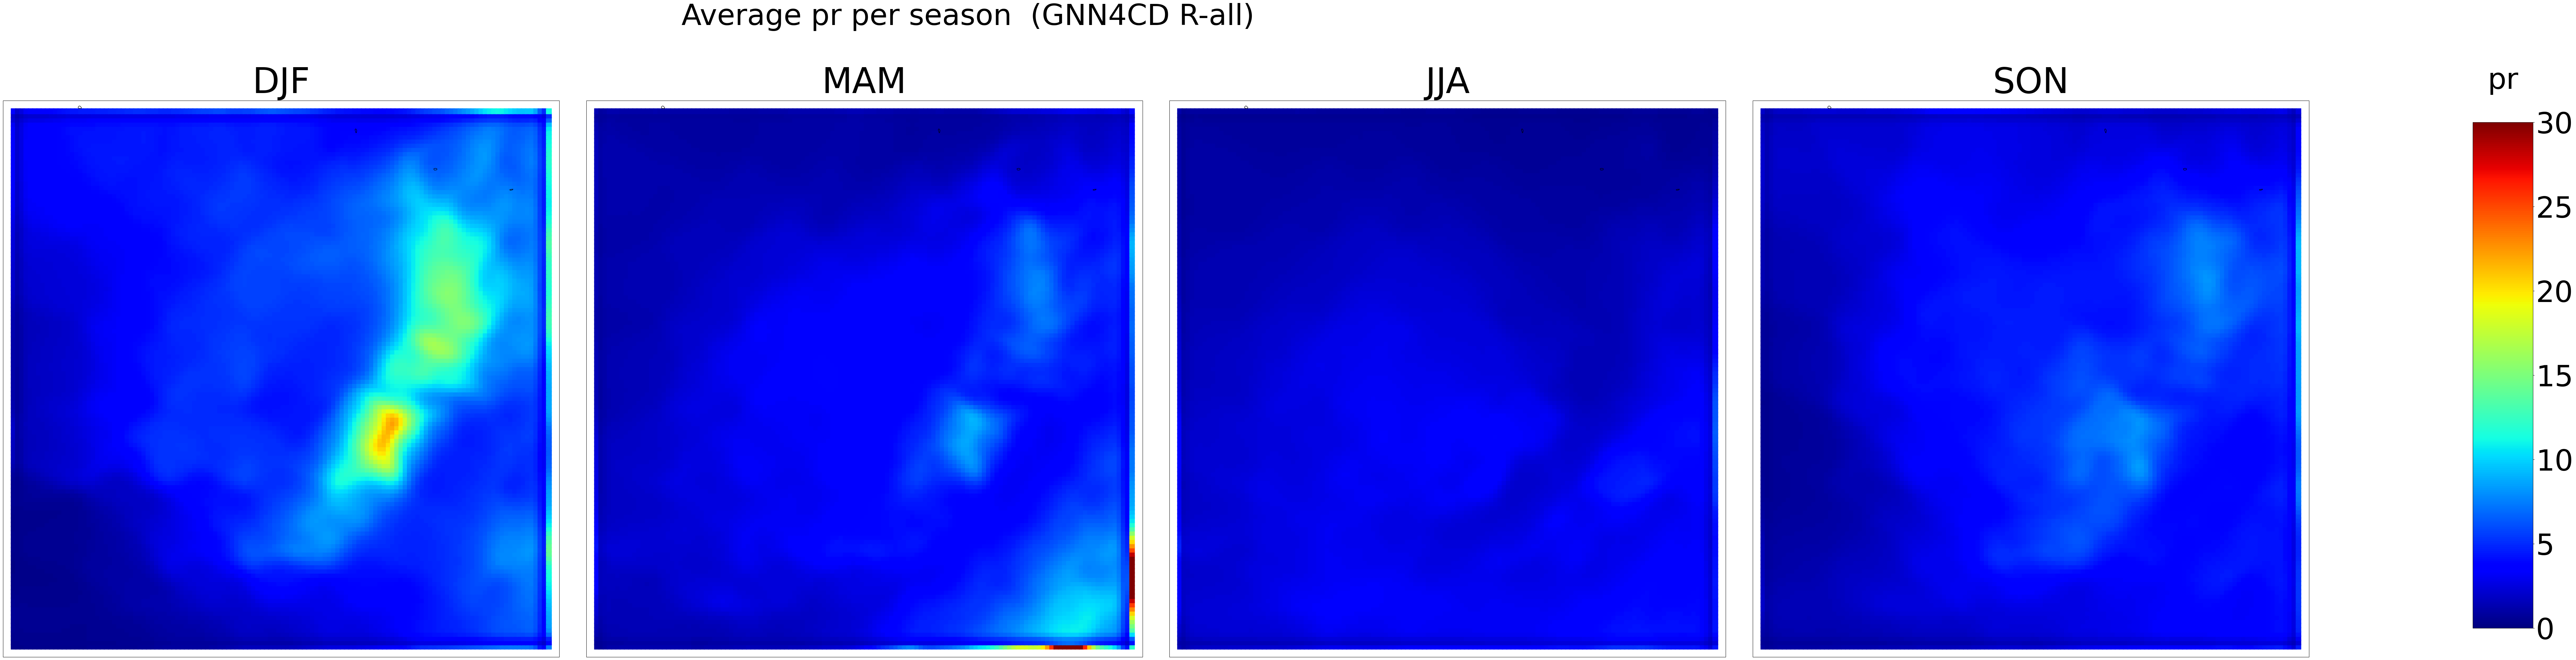

In [33]:
plot_seasonal_maps(pos, pr_pred_seasons, pr_min=pr_min, pr_max=30, title='Average pr per season  (GNN4CD R-all)', cmap='jet', unit="[mm/day]", s=150)

In [40]:
def plot_pdf_pr(y_pred, y, figname, fontsize=18, ylim=[10**(-8),5], xlabel="K"):
    plt.rcParams.update({'font.size': fontsize})

    y_pred = y_pred.flatten()
    y = y.flatten()

    bins = np.arange(260.0, 325.0, 1.0)
    #bins = np.insert(bins, 0, 0.0)
    hist_pr, bin_edges_pr = np.histogram(tasmax_pred, bins=bins, density=False)
    hist_y, bin_edges_y = np.histogram(y, bins=bins, density=False)
    
    Ntot_pr = hist_pr.sum()
    Ntot_y = hist_y.sum()
    
    bin_edges_pr_centre = (bin_edges_pr[:-1] + bin_edges_pr[1:]) / 2
    bin_edges_y_centre = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2
        
    p99_pred = np.nanpercentile(tasmax_pred, q=99)
    #p999_pred = np.nanpercentile(tasmax_pred, q=99.9)

    p99 = np.nanpercentile(y, q=99)
    p999 = np.nanpercentile(y, q=99.9)
    
    fig, ax = plt.subplots(1,figsize=(8,8))
    ax.fill_between(bin_edges_y_centre,hist_y/Ntot_y, color='grey', step="mid", alpha=0.25, label="RCM", zorder=2)
    ax.step(bin_edges_pr_centre, hist_pr/Ntot_pr, color='darkturquoise', where="mid", linewidth=1, label="GNN4CD", zorder=3)
    #ax.scatter(bin_edges_y_centre, hist_pr/Ntot_y, color='darkturquoise', s=80, label="GNN4CD", alpha=0.4, zorder=2)
    # ax.scatter(bin_edges_pr_centre, hist_pr/Ntot_pr, color='indigo', s=80, label="GNN4CD", alpha=0.4, zorder=2)
    ax.plot([p99, p99], [0,50], '-', color='gold', label='RCM - p99', zorder=1)
    ax.plot([p999, p999], [0,50], '-', color='orange', label='RCM - p99.9', zorder=1)
    #ax.plot([p99_pred, p99_pred], [0,50], '-', color='orange', label='emulator - p99', zorder=1)
    # ax.plot([p999, p999], [0,50], '-r', label='GRIPHO - p99.9', zorder=1)
    # ax.plot([p99_pred, p99_pred], [0,50], ':', color='gold', label='GNN4CD - p99', zorder=1)
    # ax.plot([p999_pred, p999_pred], [0,50], ':r', label='GNN4CD - p99.9', zorder=1)
    ax.set_yscale('log')
    #ax.set_xscale('log')
    # ax.minorticks_on()
    # ax.grid(visible=True, which='both', axis='both', color='lightgrey', zorder=0)
    ax.set_xlabel('tasmax [K]', fontsize=fontsize)
    ax.set_ylabel('frequency', fontsize=fontsize)
    plt.legend(loc='upper right', facecolor='white', framealpha=1, fontsize=16)
    #plt.savefig(figname)

    

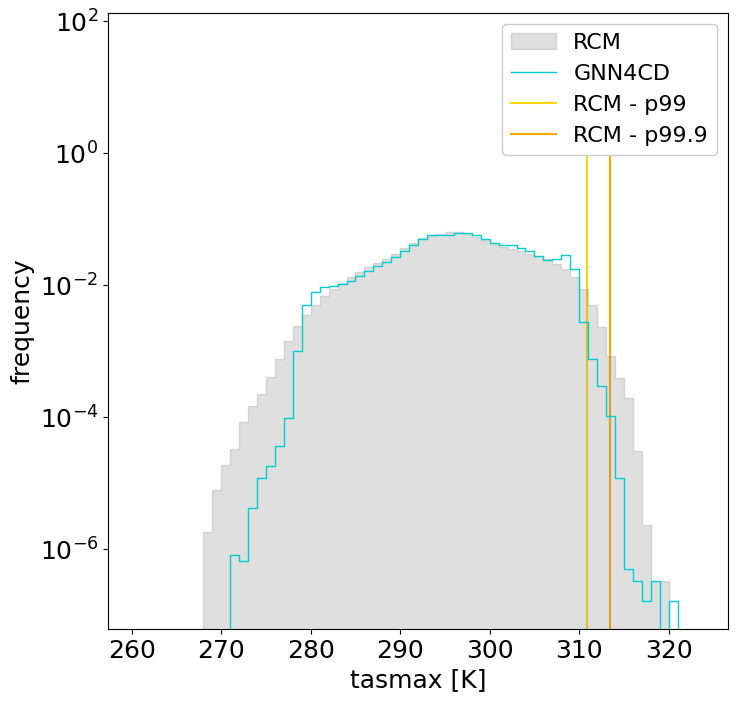

In [66]:
figname=f'test_pdf.pdf'
plot_pdf_pr(tasmax_pred, tasmax_target, figname)

In [46]:
def plot_pdf_pr_binsqloss(y_pred, y, fontsize=18, ylim=[10**(-8),5], xlabel="K"):
    plt.rcParams.update({'font.size': fontsize})

    y_pred = y_pred.flatten()
    
    y = y.flatten()
    normbins = np.arange(np.log1p(260), np.log1p(325), np.log1p(0.25))
    print(normbins[-1])

    bins= np.insert(np.expm1(normbins), 0, 0.0)
    
    hist_pr, bin_edges_pr = np.histogram(tasmax_pred, bins=bins, density=False)
    hist_y, bin_edges_y = np.histogram(y, bins=bins, density=False)
    
    Ntot_pr = hist_pr.sum()
    Ntot_y = hist_y.sum()
    
    bin_edges_pr_centre = (bin_edges_pr[:-1] + bin_edges_pr[1:]) / 2
    bin_edges_y_centre = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2
        
    p99_pred = np.nanpercentile(tasmax_pred, q=99)
    #p999_pred = np.nanpercentile(tasmax_pred, q=99.9)

    p99 = np.nanpercentile(y, q=99)
    p999 = np.nanpercentile(y, q=99.9)
    
    fig, ax = plt.subplots(1,figsize=(8,8))
    ax.fill_between(bin_edges_y_centre,hist_y/Ntot_y, color='grey', step="mid", alpha=0.25, label="RCM", zorder=2)
    ax.step(bin_edges_pr_centre, hist_pr/Ntot_pr, color='darkturquoise', where="mid", linewidth=1, label="GNN4CD", zorder=3)
    #ax.scatter(bin_edges_y_centre, hist_pr/Ntot_y, color='darkturquoise', s=80, label="GNN4CD", alpha=0.4, zorder=2)
    # ax.scatter(bin_edges_pr_centre, hist_pr/Ntot_pr, color='indigo', s=80, label="GNN4CD", alpha=0.4, zorder=2)
    ax.plot([p99, p99], [0,50], '-', color='gold', label='RCM - p99', zorder=1)
    ax.plot([p999, p999], [0,50], '-', color='orange', label='RCM - p99.9', zorder=1)
    #ax.plot([p99_pred, p99_pred], [0,50], '-', color='orange', label='emulator - p99', zorder=1)
    # ax.plot([p999, p999], [0,50], '-r', label='GRIPHO - p99.9', zorder=1)
    # ax.plot([p99_pred, p99_pred], [0,50], ':', color='gold', label='GNN4CD - p99', zorder=1)
    # ax.plot([p999_pred, p999_pred], [0,50], ':r', label='GNN4CD - p99.9', zorder=1)
    ax.set_yscale('log')
    #ax.set_xscale('log')
    # ax.minorticks_on()
    # ax.grid(visible=True, which='both', axis='both', color='lightgrey', zorder=0)
    ax.set_xlabel('tasmax [K]', fontsize=fontsize)
    ax.set_ylabel('frequency', fontsize=fontsize)
    plt.legend(loc='upper right', facecolor='white', framealpha=1, fontsize=16)
    #plt.savefig(figname)

    

5.564520407322693


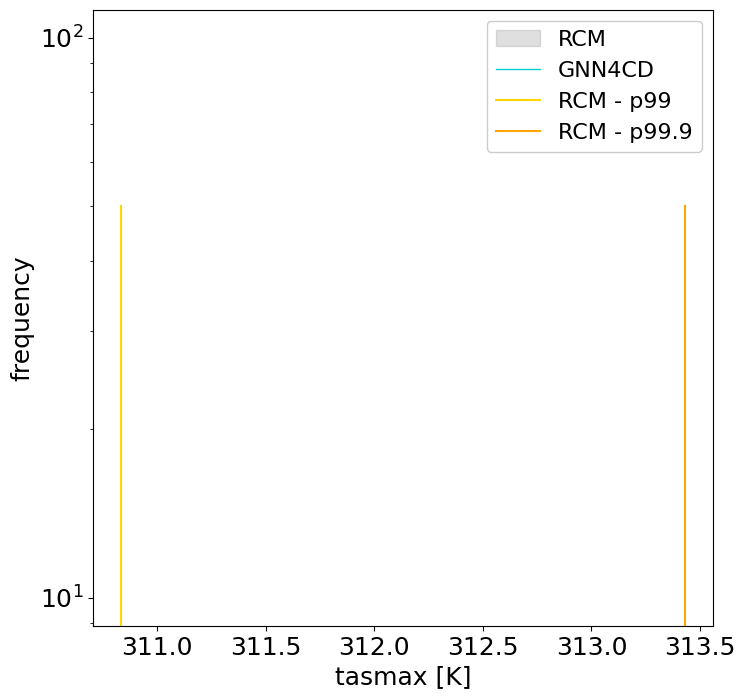

In [47]:
plot_pdf_pr_binsqloss(tasmax_pred, tasmax_target)

In [ ]:
def plot_mean_time_series(pos, pr, pr_pred, points, aggr=np.nanmean, title="Precipitation time series",color="paleturquoise"):
    
    plt.rcParams.update({'font.size': 40})
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(60,25))

    pr_mean = aggr(pr[points,:], axis=0)
    pr_pred_mean = aggr(pr_pred[points,:], axis=0)

    ticks = list(np.arange(0,31*24*12,31*24))
    labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug","Sep","Oct","Nov","Dec"]

    rmse = np.sqrt((pr_pred_mean - pr_mean)**2) * np.sign(pr_pred_mean - pr_mean)
    rmse_perc = np.sqrt((pr_pred_mean - pr_mean)**2) * np.sign(pr_pred_mean - pr_mean) / np.abs(pr_mean)

    n = pr_mean.shape[0]
    ax[0].fill_between(range(n), pr_mean, label='OBSERVATIONS', color=color)
    ax[0].plot(range(n), pr_pred_mean, label='GNN4CD', linestyle=':', color='indigo')
    ax[0].set_title(title)
    ax[0].set_ylabel("pr [mm/hr]")
    ax[0].set_xlabel("time")
    ax[0].legend(loc="upper right")
    ylim = ax[0].get_ylim()
    ax[0].set_xticks(ticks=ticks, labels=labels)
    ax[1].plot(range(n), rmse, label='RMSE',color='gold')
    ax[1].set_ylabel("RMSE [mm]")
    ax[1].set_xlabel("time")
    ax[1].legend(loc="upper right")
    ax[1].set_ylim(-ylim[1], ylim[1])
    ax[1].set_xticks(ticks=ticks, labels=labels)

    return rmse, rmse_perc

def plot_pdf_pr(pr_pred, y, fontsize=18, range=[0,200,0.5], ylim=[10**(-8),5], xlabel="[mm/h]"):
    plt.rcParams.update({'font.size': fontsize})

    pr_pred = pr_pred.flatten()
    y = y.flatten()
    
    hist_pr, bin_edges_pr = np.histogram(pr_pred, bins=np.arange(range[0],range[1],range[2]).astype(np.float32), density=False)
    hist_y, bin_edges_y = np.histogram(y, bins=np.arange(range[0],range[1],range[2]).astype(np.float32), density=False)
    
    Ntot_pr = hist_pr.sum()
    Ntot_y = hist_y.sum()
    
    bin_edges_pr_centre = (bin_edges_pr[:-1] + bin_edges_pr[1:]) / 2
    bin_edges_y_centre = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2
        
    # p99_pred = np.nanpercentile(pr_pred, q=99)
    # p999_pred = np.nanpercentile(pr_pred, q=99.9)

    # p99 = np.nanpercentile(y, q=99)
    # p999 = np.nanpercentile(y, q=99.9)
    
    fig, ax = plt.subplots(figsize=(8,8))
    plt.fill_between(bin_edges_y_centre,hist_y/Ntot_y, color='grey', step="mid", alpha=0.25, label="GRIPHO", zorder=2)
    ax.step(bin_edges_pr_centre, hist_pr/Ntot_pr, color='darkturquoise', where="mid", linewidth=1, label="GNN4CD", zorder=3)
    # ax.scatter(bin_edges_y_centre, hist_y/Ntot_y, color='darkturquoise', s=80, label="GRIPHO", alpha=0.4, zorder=2)
    # ax.scatter(bin_edges_pr_centre, hist_pr/Ntot_pr, color='indigo', s=80, label="GNN4CD", alpha=0.4, zorder=2)
    # ax.plot([p99, p99], [0,50], '-', color='gold', label='GRIPHO - p99', zorder=1)
    # ax.plot([p999, p999], [0,50], '-r', label='GRIPHO - p99.9', zorder=1)
    # ax.plot([p99_pred, p99_pred], [0,50], ':', color='gold', label='GNN4CD - p99', zorder=1)
    # ax.plot([p999_pred, p999_pred], [0,50], ':r', label='GNN4CD - p99.9', zorder=1)
    l = plt.legend(loc='upper right', facecolor='white', framealpha=1, fontsize=16)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.set_yscale('log')
    # ax.set_xscale('log')
    # ax.minorticks_on()
    # ax.grid(visible=True, which='both', axis='both', color='lightgrey', zorder=0)
    ax.set_xlabel('precipitation [mm/h]', fontsize=fontsize)
    ax.set_ylabel('frequency', fontsize=fontsize)

    return fig



In [36]:
rmse = diagnostics.rmse(x0=y_test, x1=y_pred,
                        var=var_target, dim='time')
print(f'Mean RMSE: {rmse[var_target].mean().values.item()}')

plot_data_map(data=rmse, var_name=var_target, domain=domain, vmin=0, vmax=5,
              fig_title='RMSE', cmap='Reds')

AttributeError: module 'diagnostics' has no attribute 'rmse'